# Model Analysis

This notebook includes analyses of trained RNN and SINDy models for the constant drift case (simpleDDM).

The RNNs have been trained from a ground-truth PyBeam simpleDDM model with boundary = 1.0, diffusion sigma = 1.0, non-decision time = 0.2 and evidence bias = 0.0. Drift rates are 4.0, 2.0, 1.0, 0.5 and 0.1, representing increasing difficulty in tasks.

Below we load the trained models for each drift rate. Model weights come from checkpoints saved on best KL-divergence.

We first plot the losses and accuracies of each model, followed by plots of stepwise drift and diffusion values of the RNN. Then, we fit a SINDy model to these values and display the discovered equation, as well as their initial values. We then simulate new choice-RTs from the RNN and the SINDy models, which we use later for model recovery and comparison.

### Loss and Accuracy Plots

The following plots show the training losses and accuracies of the RNNs and the discriminators. The RNN loss is the KL-divergence between the simulated RTs and the target RTs, while the discriminator loss is the percentage of batches in an epoch where the discriminator scored the real RTs higher than the RNN predictions.

In [2]:
path_4_0 = 'experiments/final/20250402-003302_v4_0'
path_2_0 = 'experiments/final/20250401-014407_v2_0'
path_1_0 = 'experiments/final/20250401-034628_v1_0'
path_0_5 = 'experiments/final/20250401-170505_v0_5'
path_0_1 = 'experiments/final/20250401-151430_v0_1'
paths = [path_4_0, path_2_0, path_1_0, path_0_5, path_0_1]

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import yaml

from training_utils import get_lls

from regressors import RNNRegressor

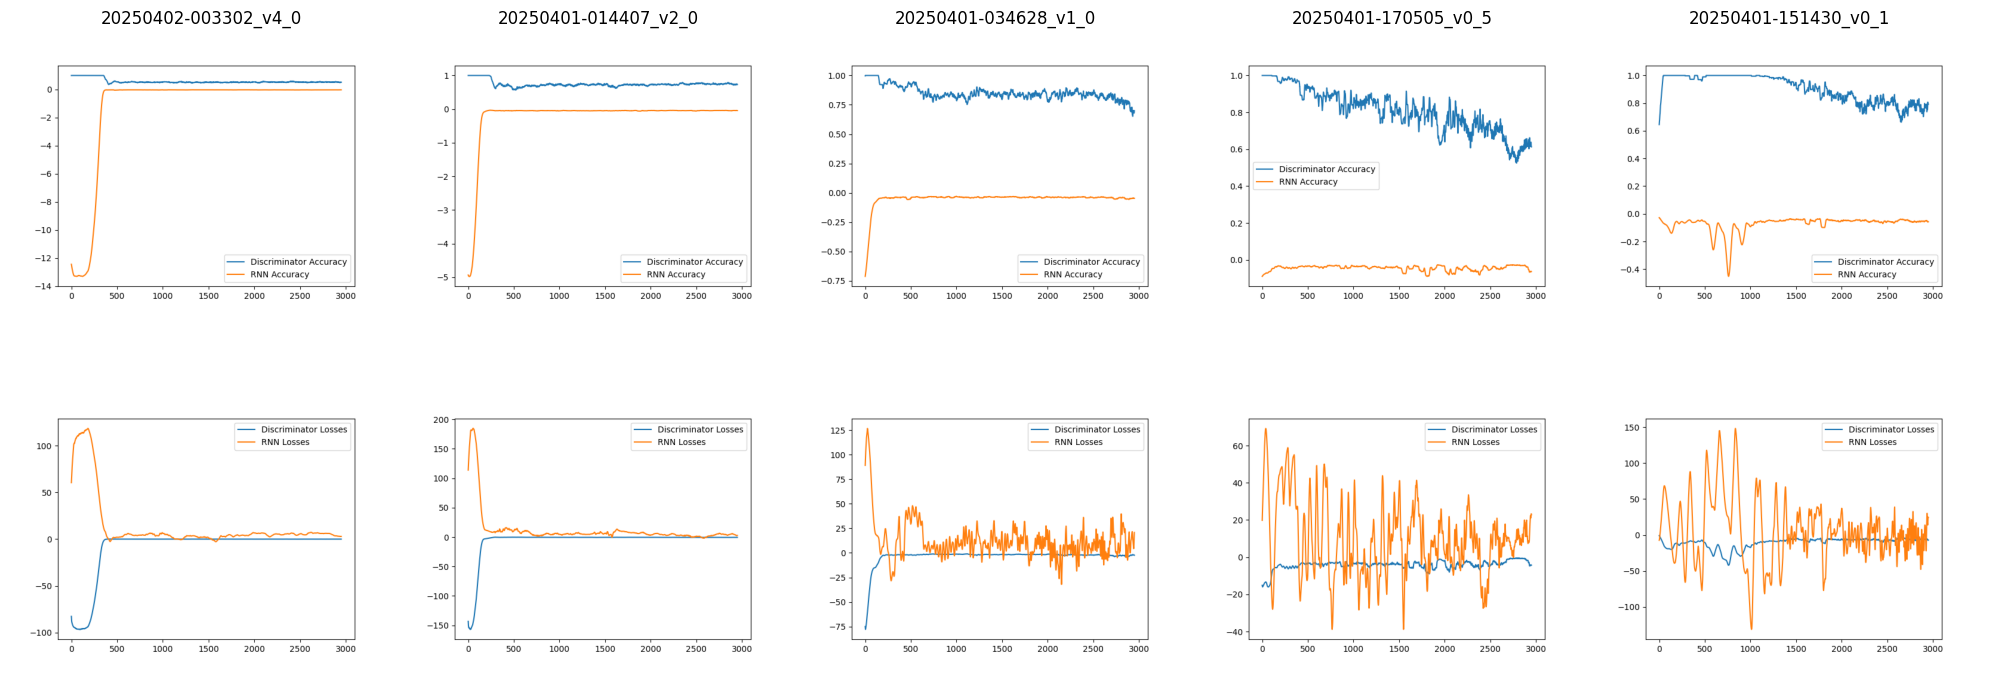

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, path in enumerate(paths):
    acc_path = f'../../{path}/figures/acc.png'
    loss_path = f'../../{path}/figures/loss.png'

    acc_img = plt.imread(acc_path)
    loss_img = plt.imread(loss_path)

    axes[0, i].imshow(acc_img)
    axes[0, i].axis('off')
    axes[0, i].set_title(path.split('/')[-1])

    axes[1, i].imshow(loss_img)
    axes[1, i].axis('off')

# Hide the last empty subplot
    if i == len(paths) - 1:
        for ax in axes[0, i+1:]:
            ax.axis('off')
        for ax in axes[1, i+1:]:
            ax.axis('off')
plt.tight_layout()
plt.show()

## Parameter Recovery

The following plots show the stepwise drift and diffusion values that the RNNs have learned. Each are taken from the first sequence. The threshold is also plotted for convenience.

### Load Models

First, we need to load the trained RNNs and their corresponding RTs. The RTs are used to simulate the same number of choice-RTs from the RNNs and later plot real and predicted RT distributions.

In [4]:
def load_rnn_regressor(experiment, device='cpu', min_dt=0.01, ln_dim=1):
    # Set paths
    checkpoint_load_path = f'../../{experiment}/checkpoint.pth'
    rt_load_path = f'../../{experiment}/rt.npy'
    config_file_path = f'../../{experiment}/config.yml'

    # Load config file
    with open(config_file_path, "r") as file:
        config = yaml.safe_load(file)

    rts_original = np.load(rt_load_path)
    t_max = np.max(abs(rts_original))

    rnn_regressor = RNNRegressor(hidden_dim=config['rnn_params']['hidden_dim'],
                                 hidden_layers=config['rnn_params']['hidden_layers'],
                                 lr=config['training_params']['lr'],
                                 batch_size=config['rnn_params']['batch_size'],
                                 train_interval=config['training_params']['train_interval'],
                                 init_evidence=0.,
                                 threshold=1.,
                                 t_max=t_max,
                                 checkpoint_load_path=checkpoint_load_path,
                                 save_path=None,
                                 device=device,
                                 logger=None,
                                 verbose=True,
                                 min_dt=min_dt,
                                 ln_dim=ln_dim)

    return rnn_regressor, rts_original, config, t_max

In [5]:
rnn_regressor_4_0, rts_original_4_0, config_4_0, t_max_4_0 = load_rnn_regressor(path_4_0)
rnn_regressor_2_0, rts_original_2_0, config_2_0, t_max_2_0 = load_rnn_regressor(path_2_0)
rnn_regressor_1_0, rts_original_1_0, config_1_0, t_max_1_0 = load_rnn_regressor(path_1_0)
rnn_regressor_0_5, rts_original_0_5, config_0_5, t_max_0_5 = load_rnn_regressor(path_0_5)
rnn_regressor_0_1, rts_original_0_1, config_0_1, t_max_0_1 = load_rnn_regressor(path_0_1)

Loaded checkpoint from ../../experiments/final/20250402-003302_v4_0/checkpoint.pth
Loaded checkpoint from ../../experiments/final/20250401-014407_v2_0/checkpoint.pth
Loaded checkpoint from ../../experiments/final/20250401-034628_v1_0/checkpoint.pth
Loaded checkpoint from ../../experiments/final/20250401-170505_v0_5/checkpoint.pth
Loaded checkpoint from ../../experiments/final/20250401-151430_v0_1/checkpoint.pth


### Simulate RTs from RNNs

In [6]:
rts_rnn_4_0, traces_rnn_4_0, dt_rnn_4_0 = rnn_regressor_4_0.predict(np.zeros(len(rts_original_4_0)))
rts_rnn_2_0, traces_rnn_2_0, dt_rnn_2_0 = rnn_regressor_2_0.predict(np.zeros(len(rts_original_2_0)))
rts_rnn_1_0, traces_rnn_1_0, dt_rnn_1_0 = rnn_regressor_1_0.predict(np.zeros(len(rts_original_1_0)))
rts_rnn_0_5, traces_rnn_0_5, dt_rnn_0_5 = rnn_regressor_0_5.predict(np.zeros(len(rts_original_0_5)))
rts_rnn_0_1, traces_rnn_0_1, dt_rnn_0_1 = rnn_regressor_0_1.predict(np.zeros(len(rts_original_0_1)))

Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.


In [7]:
rts_rnn_4_0 = rts_rnn_4_0.reshape(-1, 1)
rts_rnn_2_0 = rts_rnn_2_0.reshape(-1, 1)
rts_rnn_1_0 = rts_rnn_1_0.reshape(-1, 1)
rts_rnn_0_5 = rts_rnn_0_5.reshape(-1, 1)
rts_rnn_0_1 = rts_rnn_0_1.reshape(-1, 1)

### Stepwise Drift and Diffusion Plots

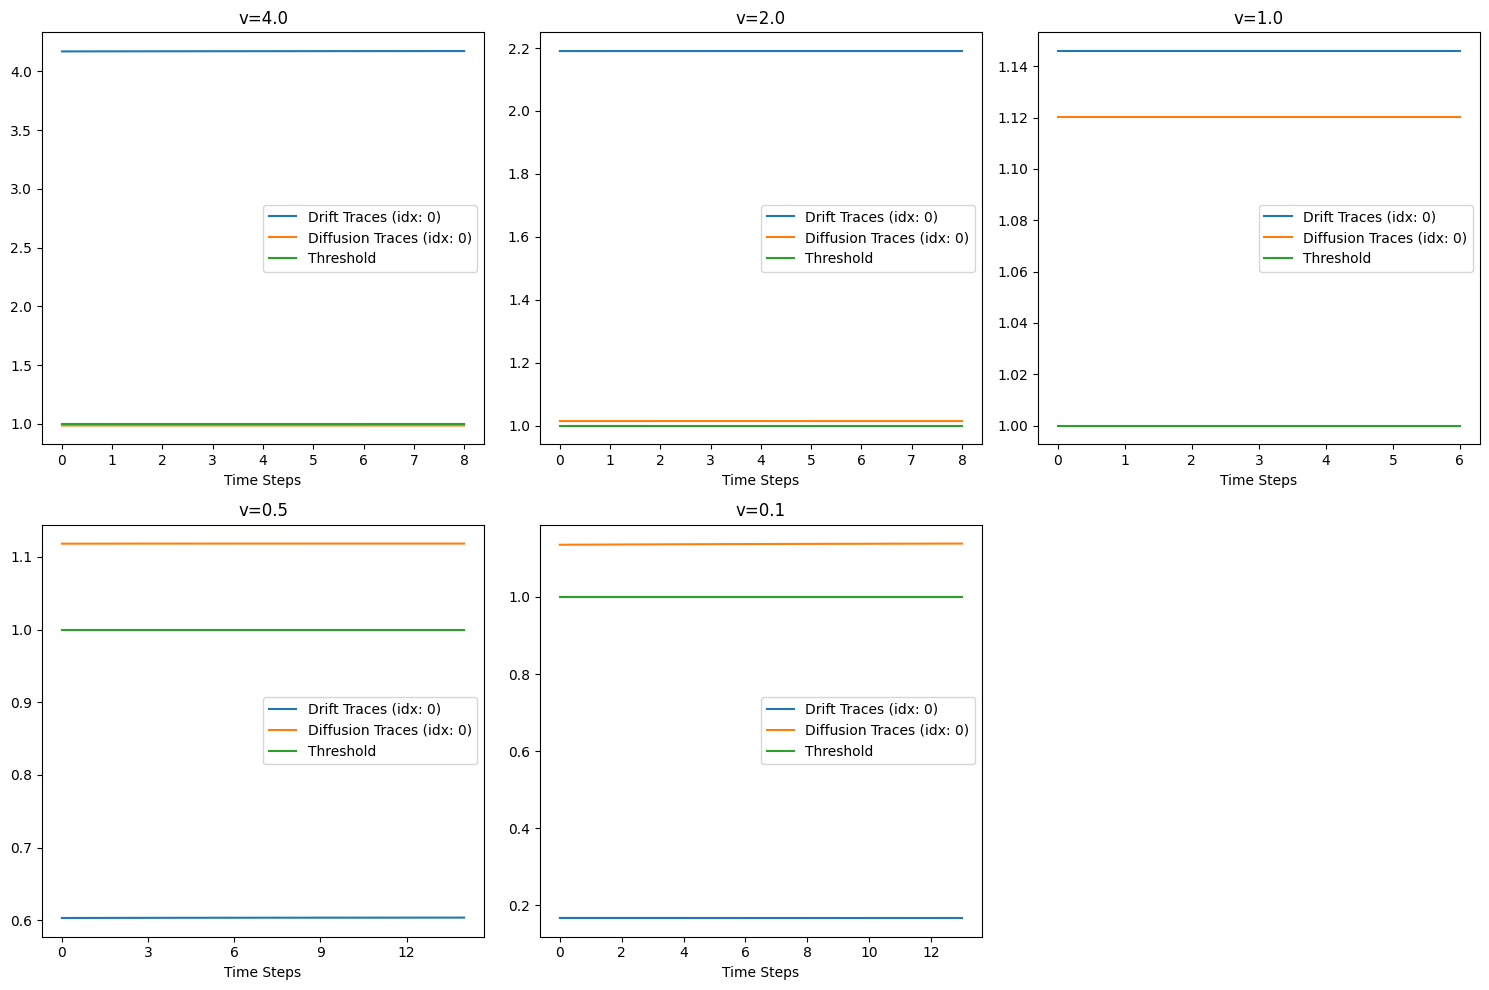

In [8]:
def plot_traces(traces_dict):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    axes = axes.flatten()

    for ax, (label, (rnn_regressor, traces)) in zip(axes, traces_dict.items()):
        idx = 0
        seq = traces['evidence'][idx].size
        drifts = traces['drift'][idx, :seq, 0]
        diffusions = traces['drift'][idx, :seq, 1]
        threshold = rnn_regressor.rnn.threshold.detach().cpu().numpy()

        ax.plot(drifts, label='Drift Traces (idx: 0)')
        ax.plot(diffusions, label='Diffusion Traces (idx: 0)')
        ax.plot(np.full(drifts.shape, threshold), label='Threshold')
        ax.set_title(label)
        ax.set_xlabel('Time Steps')
        ax.legend()

        ax.set_xticks(np.arange(0, seq, step=max(1, seq // 5)))

    # Hide the last empty subplot
    if len(traces_dict) < len(axes):
        for ax in axes[len(traces_dict):]:
            ax.axis('off')

    plt.tight_layout()
    plt.show()

traces_dict = {
    "v=4.0": [rnn_regressor_4_0, traces_rnn_4_0],
    "v=2.0": [rnn_regressor_2_0, traces_rnn_2_0],
    "v=1.0": [rnn_regressor_1_0, traces_rnn_1_0],
    "v=0.5": [rnn_regressor_0_5, traces_rnn_0_5],
    "v=0.1": [rnn_regressor_0_1, traces_rnn_0_1]
}

plot_traces(traces_dict)

As we can see, the RNNs have learned to approximate the stepwise drift and diffusion values of the PyBeam model and they are constant across time steps.

In [9]:
import pandas as pd

def create_df(traces_dict):
    data = {
        'Drift Mean': [],
        'Drift Std': [],
        'Diffusion Mean': [],
        'Diffusion Std': [],
        'Drift / Diffusion': []
    }

    for label, (rnn_regressor, traces) in traces_dict.items():
        drift_means = []
        drift_stds = []
        diffusion_means = []
        diffusion_stds = []
        for idx in range(len(traces['evidence'])):
            seq = traces['evidence'][idx].size
            drifts = traces['drift'][idx, :seq, 0]
            diffusions = traces['drift'][idx, :seq, 1]

            drift_means.append(np.mean(drifts))
            drift_stds.append(np.std(drifts))
            diffusion_means.append(np.mean(diffusions))
            diffusion_stds.append(np.std(diffusions))

        data['Drift Mean'].append(np.mean(drift_means))
        data['Drift Std'].append(np.mean(drift_stds))
        data['Diffusion Mean'].append(np.mean(diffusion_means))
        data['Diffusion Std'].append(np.mean(diffusion_stds))
        data['Drift / Diffusion'].append(np.mean(drift_means) / np.mean(diffusion_means))

    df = pd.DataFrame(data, index=traces_dict.keys())
    return df

In [10]:
df = create_df(traces_dict)

In [11]:
df

,Drift Mean,Drift Std,Diffusion Mean,Diffusion Std,Drift / Diffusion
v=4.0,4.172721,1.214172e-03,0.986753,7.857836e-05,4.228741
v=2.0,2.190527,8.966414e-06,1.014098,1.064746e-05,2.160075
v=1.0,1.145921,4.134199e-08,1.120116,3.892637e-08,1.023037
v=0.5,0.603636,1.395920e-04,1.118148,3.936581e-05,0.539853
v=0.1,0.166658,4.076882e-05,1.137559,9.779243e-04,0.146505


### Fit SINDy model

The following code fits a SINDy model to the drift and diffusion values of the RNNs. The SINDy model is a sparse regression model that learns the underlying dynamics of the system. The SINDy model is fitted to the drift and diffusion values of the RNNs and the discovered equation is displayed.

In [12]:
from regressors import SindyRegressor
from plotting import plot_rts_multi
import logging

# Set logging
logger = logging.getLogger(__name__)
if not logger.handlers:
    logger.setLevel(logging.DEBUG)

    ch = logging.StreamHandler()
    ch.setLevel(logging.INFO)

    logger.addHandler(ch)

# v=4.0
sindy_regressor_4_0 = SindyRegressor.from_params(dt=float(dt_rnn_4_0[0]),
                                             training_params=config_4_0['sindy_params']['training'],
                                             simulation_params=config_4_0['ddm_params'],
                                             t_max=t_max_4_0,
                                             device='cpu',
                                             verbose=False,
                                             logger=None)
print('Fitting SINDy model for v = 4.0...')
sindy_regressor_4_0.fit(traces_rnn_4_0['drift'])
print('Equations for v = 4.0:')
sindy_regressor_4_0.sindy.print()

# v=2.0
sindy_regressor_2_0 = SindyRegressor.from_params(dt=float(dt_rnn_2_0[0]),
                                             training_params=config_2_0['sindy_params']['training'],
                                             simulation_params=config_2_0['ddm_params'],
                                             t_max=t_max_2_0,
                                             device='cpu',
                                             verbose=False,
                                             logger=None)
print('Fitting SINDy model for v = 2.0...')
sindy_regressor_2_0.fit(traces_rnn_2_0['drift'])
print('Done. Equations for v = 2.0:')
sindy_regressor_2_0.sindy.print()

# v=1.0
sindy_regressor_1_0 = SindyRegressor.from_params(dt=float(dt_rnn_1_0[0]),
                                             training_params=config_1_0['sindy_params']['training'],
                                             simulation_params=config_1_0['ddm_params'],
                                             t_max=t_max_1_0,
                                             device='cpu',
                                             verbose=False,
                                             logger=None)
print('Fitting SINDy model for v = 1.0...')
sindy_regressor_1_0.fit(traces_rnn_1_0['drift'])
print('Done. Equations for v = 1.0:')
sindy_regressor_1_0.sindy.print()

# v=0.5
sindy_regressor_0_5 = SindyRegressor.from_params(dt=float(dt_rnn_0_5[0]),
                                             training_params=config_0_5['sindy_params']['training'],
                                             simulation_params=config_0_5['ddm_params'],
                                             t_max=t_max_0_5,
                                             device='cpu',
                                             verbose=False,
                                             logger=None)
print('Fitting SINDy model for v = 0.5...')
sindy_regressor_0_5.fit(traces_rnn_0_5['drift'])
print('Done. Equations for v = 0.5:')
sindy_regressor_0_5.sindy.print()

# v=0.1
sindy_regressor_0_1 = SindyRegressor.from_params(dt=float(dt_rnn_0_1[0]),
                                             training_params=config_0_1['sindy_params']['training'],
                                             simulation_params=config_0_1['ddm_params'],
                                             t_max=t_max_0_1,
                                             device='cpu',
                                             verbose=False,
                                             logger=None)
print('Fitting SINDy model for v = 0.1...')
sindy_regressor_0_1.fit(traces_rnn_0_1['drift'])
print('Done. Equations for v = 0.1:')
sindy_regressor_0_1.sindy.print()

Fitting SINDy model for v = 4.0...
Equations for v = 4.0:
(v)[k+1] = 1.000 v[k]
(sigma)[k+1] = 1.000 sigma[k]
Fitting SINDy model for v = 2.0...
Done. Equations for v = 2.0:
(v)[k+1] = 1.000 v[k]
(sigma)[k+1] = 1.000 sigma[k]
Fitting SINDy model for v = 1.0...
Done. Equations for v = 1.0:
(v)[k+1] = 1.134
(sigma)[k+1] = 1.047
Fitting SINDy model for v = 0.5...
Done. Equations for v = 0.5:
(v)[k+1] = 1.000 v[k]
(sigma)[k+1] = 1.000 sigma[k]
Fitting SINDy model for v = 0.1...
Done. Equations for v = 0.1:
(v)[k+1] = 1.000 v[k]
(sigma)[k+1] = 1.000 sigma[k]


### Predict from SINDy

Now that we have fitted the SINDy model, we can use it to predict stepwise drift and diffusion values. We will also calculate new choice-RTs from the SINDy model, which we will use later for model recovery and comparison.

In [13]:
def sindy_predict(sindy, initial_v=0.5, initial_D=1.0, b=1.0, tnd=0.2, n_sims=8192, dt=0.1):
    rts = []

    for i in range(n_sims):
        v_t = initial_v
        D_t = initial_D
        x = 0
        count = 0
        while abs(x) < b:
            v_t = np.array(v_t).reshape(1, 1, 1)
            D_t = np.array(D_t).reshape(1, 1, 1)

            v_t, D_t = sindy.predict(np.concatenate((v_t, D_t), axis=-1), multiple_trajectories=False).squeeze()
            x += v_t * dt + D_t * np.sqrt(dt) * np.random.randn()
            count += 1
        rt = (tnd + dt * count) * np.sign(x)
        rts.append(rt)

    return rts

In [14]:
v_init_4_0, D_init_4_0 = traces_rnn_4_0['drift'][0][0]
v_init_2_0, D_init_2_0 = traces_rnn_2_0['drift'][0][0]
v_init_1_0, D_init_1_0 = traces_rnn_1_0['drift'][0][0]
v_init_0_5, D_init_0_5 = traces_rnn_0_5['drift'][0][0]
v_init_0_1, D_init_0_1 = traces_rnn_0_1['drift'][0][0]

In [15]:
rts_sindy_4_0 = sindy_predict(sindy_regressor_4_0.sindy, initial_v=v_init_4_0, initial_D=D_init_4_0, b=rnn_regressor_4_0.rnn.threshold.item(), dt=dt_rnn_4_0[0])
rts_sindy_2_0 = sindy_predict(sindy_regressor_2_0.sindy, initial_v=v_init_2_0, initial_D=D_init_2_0, b=rnn_regressor_2_0.rnn.threshold.item(), dt=dt_rnn_2_0[0])
rts_sindy_1_0 = sindy_predict(sindy_regressor_1_0.sindy, initial_v=v_init_1_0, initial_D=D_init_1_0, b=rnn_regressor_1_0.rnn.threshold.item(), dt=dt_rnn_1_0[0])
rts_sindy_0_5 = sindy_predict(sindy_regressor_0_5.sindy, initial_v=v_init_0_5, initial_D=D_init_0_5, b=rnn_regressor_0_5.rnn.threshold.item(), dt=dt_rnn_0_5[0])
rts_sindy_0_1 = sindy_predict(sindy_regressor_0_1.sindy, initial_v=v_init_0_1, initial_D=D_init_0_1, b=rnn_regressor_0_1.rnn.threshold.item(), dt=dt_rnn_0_1[0])

In [16]:
rts_sindy_4_0 = np.array(rts_sindy_4_0).reshape(-1, 1)
rts_sindy_2_0 = np.array(rts_sindy_2_0).reshape(-1, 1)
rts_sindy_1_0 = np.array(rts_sindy_1_0).reshape(-1, 1)
rts_sindy_0_5 = np.array(rts_sindy_0_5).reshape(-1, 1)
rts_sindy_0_1 = np.array(rts_sindy_0_1).reshape(-1, 1)

### Plot Response Time Distributions from RNN and SINDy

Below we plot the response time distributions from the RNN and SINDy models, as well as the original RTs from the PyBeam model. The distributions are plotted as histograms.

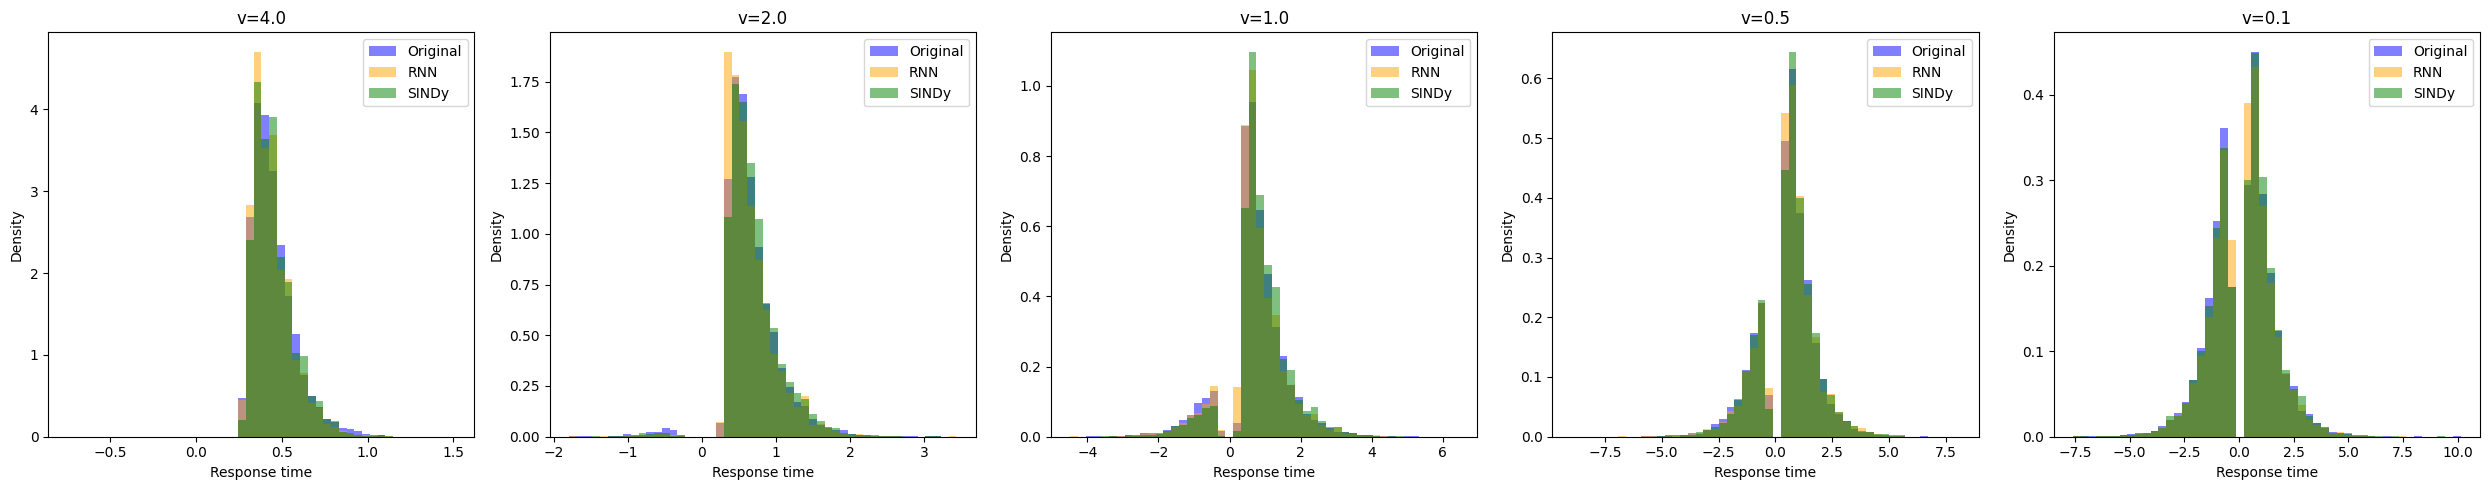

In [17]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

rt_dicts = [
    {
        'rts': [rts_original_4_0, rts_rnn_4_0, rts_sindy_4_0],
        'labels': ['Original', 'RNN', 'SINDy'],
        'colors': ['blue', 'orange', 'green'],
        'label': 'v=4.0'
    },
    {
        'rts': [rts_original_2_0, rts_rnn_2_0, rts_sindy_2_0],
        'labels': ['Original', 'RNN', 'SINDy'],
        'colors': ['blue', 'orange', 'green'],
        'label': 'v=2.0'
    },
    {
        'rts': [rts_original_1_0, rts_rnn_1_0, rts_sindy_1_0],
        'labels': ['Original', 'RNN', 'SINDy'],
        'colors': ['blue', 'orange', 'green'],
        'label': 'v=1.0'
    },
    {
        'rts': [rts_original_0_5, rts_rnn_0_5, rts_sindy_0_5],
        'labels': ['Original', 'RNN', 'SINDy'],
        'colors': ['blue', 'orange', 'green'],
        'label': 'v=0.5'
    },
    {
        'rts': [rts_original_0_1, rts_rnn_0_1, rts_sindy_0_1],
        'labels': ['Original', 'RNN', 'SINDy'],
        'colors': ['blue', 'orange', 'green'],
        'label': 'v=0.1'
    }
]

for ax, rt_dict in zip(axes, rt_dicts):
    plot_rts_multi(ax, rt_dict)
    ax.set_title(rt_dict['label'])

plt.tight_layout()
plt.show()
plt.close()

## Model Recovery

In this section, we will see how well the RNN and SINDy models performs in terms of log-likelihood on their own data. For comparison, we also fit a simple DDM and a full DDM model to the original data. We then fit Kernel Density Estimation (KDE) to the RTs from each model, as well as the original data. The KDE is used to estimate the probability density function of the RTs. Then, we score the log-likelihood of the KDE on the RTs from each model. The log-likelihood is a measure of how well the model fits the data. A higher log-likelihood indicates a better fit. Finally we create a heatmap from the results, comparing how well each model can fit the data from the other models.

### Fit SimpleDDM to Original Data

The following code fits a simpleDDM model to the original data and generates new choice-RTs from it. The simpleDDM model is the same model that the original data was generated from, so we expect it to have a good fit.

In [18]:
import pybeam.precoded as pbp
import pybeam.custom as pbc

Let's load parameter sets for all drift rates. The parameters are the same as the ones used to generate the original data.

In [19]:
phi_4_0 = {
    'phi[0]': config_4_0['ddm_params']['tnd'],
    'phi[1]': config_4_0['ddm_params']['starting_point'],
    'phi[2]': config_4_0['ddm_params']['drift'],
    'phi[3]': config_4_0['ddm_params']['diffusion'],
    'phi[4]': config_4_0['ddm_params']['boundary']
}
phi_2_0 = {
    'phi[0]': config_2_0['ddm_params']['tnd'],
    'phi[1]': config_2_0['ddm_params']['starting_point'],
    'phi[2]': config_2_0['ddm_params']['drift'],
    'phi[3]': config_2_0['ddm_params']['diffusion'],
    'phi[4]': config_2_0['ddm_params']['boundary']
}
phi_1_0 = {
    'phi[0]': config_1_0['ddm_params']['tnd'],
    'phi[1]': config_1_0['ddm_params']['starting_point'],
    'phi[2]': config_1_0['ddm_params']['drift'],
    'phi[3]': config_1_0['ddm_params']['diffusion'],
    'phi[4]': config_1_0['ddm_params']['boundary']
}
phi_0_5 = {
    'phi[0]': config_0_5['ddm_params']['tnd'],
    'phi[1]': config_0_5['ddm_params']['starting_point'],
    'phi[2]': config_0_5['ddm_params']['drift'],
    'phi[3]': config_0_5['ddm_params']['diffusion'],
    'phi[4]': config_0_5['ddm_params']['boundary']
}
phi_0_1 = {
    'phi[0]': config_0_1['ddm_params']['tnd'],
    'phi[1]': config_0_1['ddm_params']['starting_point'],
    'phi[2]': config_0_1['ddm_params']['drift'],
    'phi[3]': config_0_1['ddm_params']['diffusion'],
    'phi[4]': config_0_1['ddm_params']['boundary']
}

In [20]:
model_dir_4_0 = f'../../{config_4_0["simulation_params"]["path_pybeam_model"]}'
model_dir_2_0 = f'../../{config_2_0["simulation_params"]["path_pybeam_model"]}'
model_dir_1_0 = f'../../{config_1_0["simulation_params"]["path_pybeam_model"]}'
model_dir_0_5 = f'../../{config_0_5["simulation_params"]["path_pybeam_model"]}'
model_dir_0_1 = f'../../{config_0_1["simulation_params"]["path_pybeam_model"]}'

In [65]:
rts_original_4_0_upper = rts_original_4_0[rts_original_4_0 >= 0]
rts_original_4_0_lower = -1 * rts_original_4_0[rts_original_4_0 < 0]
rts_original_2_0_upper = rts_original_2_0[rts_original_2_0 >= 0]
rts_original_2_0_lower = -1 * rts_original_2_0[rts_original_2_0 < 0]
rts_original_1_0_upper = rts_original_1_0[rts_original_1_0 >= 0]
rts_original_1_0_lower = -1 * rts_original_1_0[rts_original_1_0 < 0]
rts_original_0_5_upper = rts_original_0_5[rts_original_0_5 >= 0]
rts_original_0_5_lower = -1 * rts_original_0_5[rts_original_0_5 < 0]
rts_original_0_1_upper = rts_original_0_1[rts_original_0_1 >= 0]
rts_original_0_1_lower = -1 * rts_original_0_1[rts_original_0_1 < 0]

rts_rnn_4_0_upper = rts_rnn_4_0[rts_rnn_4_0 >= 0]
rts_rnn_4_0_lower = -1 * rts_rnn_4_0[rts_rnn_4_0 < 0]
rts_rnn_2_0_upper = rts_rnn_2_0[rts_rnn_2_0 >= 0]
rts_rnn_2_0_lower = -1 * rts_rnn_2_0[rts_rnn_2_0 < 0]
rts_rnn_1_0_upper = rts_rnn_1_0[rts_rnn_1_0 >= 0]
rts_rnn_1_0_lower = -1 * rts_rnn_1_0[rts_rnn_1_0 < 0]
rts_rnn_0_5_upper = rts_rnn_0_5[rts_rnn_0_5 >= 0]
rts_rnn_0_5_lower = -1 * rts_rnn_0_5[rts_rnn_0_5 < 0]
rts_rnn_0_1_upper = rts_rnn_0_1[rts_rnn_0_1 >= 0]
rts_rnn_0_1_lower = -1 * rts_rnn_0_1[rts_rnn_0_1 < 0]

rts_sindy_4_0_upper = rts_sindy_4_0[rts_sindy_4_0 >= 0]
rts_sindy_4_0_lower = -1 * rts_sindy_4_0[rts_sindy_4_0 < 0]
rts_sindy_2_0_upper = rts_sindy_2_0[rts_sindy_2_0 >= 0]
rts_sindy_2_0_lower = -1 * rts_sindy_2_0[rts_sindy_2_0 < 0]
rts_sindy_1_0_upper = rts_sindy_1_0[rts_sindy_1_0 >= 0]
rts_sindy_1_0_lower = -1 * rts_sindy_1_0[rts_sindy_1_0 < 0]
rts_sindy_0_5_upper = rts_sindy_0_5[rts_sindy_0_5 >= 0]
rts_sindy_0_5_lower = -1 * rts_sindy_0_5[rts_sindy_0_5 < 0]
rts_sindy_0_1_upper = rts_sindy_0_1[rts_sindy_0_1 >= 0]
rts_sindy_0_1_lower = -1 * rts_sindy_0_1[rts_sindy_0_1 < 0]

In [66]:
ll_pbc_4_0_original = pbc.loglikelihood(model_dir=model_dir_4_0, phi=phi_4_0, rt={'rt_upper': rts_original_4_0_upper, 'rt_lower': -1 * rts_original_4_0_lower})
ll_pbc_4_0_rnn = pbc.loglikelihood(model_dir=model_dir_4_0, phi=phi_4_0, rt={'rt_upper': rts_rnn_4_0_upper, 'rt_lower': -1 * rts_rnn_4_0_lower})
ll_pbc_4_0_sindy = pbc.loglikelihood(model_dir=model_dir_4_0, phi=phi_4_0, rt={'rt_upper': rts_sindy_4_0_upper, 'rt_lower': -1 * rts_sindy_4_0_lower})
print(f'v = 4.0 \n LL - Original: {ll_pbc_4_0_original} \n LL - RNN: {ll_pbc_4_0_rnn} \n LL - SINDy: {ll_pbc_4_0_sindy}')

v = 4.0 
 LL - Original: 6671.977104809402 
 LL - RNN: 7122.983379565249 
 LL - SINDy: 6869.652270486964


In [67]:
ll_pbc_2_0_original = pbc.loglikelihood(model_dir=model_dir_2_0, phi=phi_2_0, rt={'rt_upper': rts_original_2_0_upper, 'rt_lower': -1 * rts_original_2_0_lower})
ll_pbc_2_0_rnn = pbc.loglikelihood(model_dir=model_dir_2_0, phi=phi_2_0, rt={'rt_upper': rts_rnn_2_0_upper, 'rt_lower': -1 * rts_rnn_2_0_lower})
ll_pbc_2_0_sindy = pbc.loglikelihood(model_dir=model_dir_2_0, phi=phi_2_0, rt={'rt_upper': rts_sindy_2_0_upper, 'rt_lower': -1 * rts_sindy_2_0_lower})
print(f'v = 2.0 \n LL - Original: {ll_pbc_2_0_original} \n LL - RNN: {ll_pbc_2_0_rnn} \n LL - SINDy: {ll_pbc_2_0_sindy}')

v = 2.0 
 LL - Original: -2071.7867308197297 
 LL - RNN: -1104.1102809178399 
 LL - SINDy: -1535.5864075503207


In [68]:
ll_pbc_1_0_original = pbc.loglikelihood(model_dir=model_dir_1_0, phi=phi_1_0, rt={'rt_upper': rts_original_1_0_upper, 'rt_lower': -1 * rts_original_1_0_lower})
ll_pbc_1_0_rnn = pbc.loglikelihood(model_dir=model_dir_1_0, phi=phi_1_0, rt={'rt_upper': rts_rnn_1_0_upper, 'rt_lower': -1 * rts_rnn_1_0_lower})
ll_pbc_1_0_sindy = pbc.loglikelihood(model_dir=model_dir_1_0, phi=phi_1_0, rt={'rt_upper': rts_sindy_1_0_upper, 'rt_lower': -1 * rts_sindy_1_0_lower})
print(f'v = 1.0 \n LL - Original: {ll_pbc_1_0_original} \n LL - RNN: {ll_pbc_1_0_rnn} \n LL - SINDy: {ll_pbc_1_0_sindy}')

v = 1.0 
 LL - Original: -16575.612611406592 
 LL - RNN: -15895.056598352863 
 LL - SINDy: -13967.38919505229


In [69]:
ll_pbc_0_5_original = pbc.loglikelihood(model_dir=model_dir_0_5, phi=phi_0_5, rt={'rt_upper': rts_original_0_5_upper, 'rt_lower': -1 * rts_original_0_5_lower})
ll_pbc_0_5_rnn = pbc.loglikelihood(model_dir=model_dir_0_5, phi=phi_0_5, rt={'rt_upper': rts_rnn_0_5_upper, 'rt_lower': -1 * rts_rnn_0_5_lower})
ll_pbc_0_5_sindy = pbc.loglikelihood(model_dir=model_dir_0_5, phi=phi_0_5, rt={'rt_upper': rts_sindy_0_5_upper, 'rt_lower': -1 * rts_sindy_0_5_lower})
print(f'v = 0.5 \n LL - Original: {ll_pbc_0_5_original} \n LL - RNN: {ll_pbc_0_5_rnn} \n LL - SINDy: {ll_pbc_0_5_sindy}')

v = 0.5 
 LL - Original: -31518.667782598324 
 LL - RNN: -30619.35853975013 
 LL - SINDy: -30339.65023493398


In [70]:
ll_pbc_0_1_original = pbc.loglikelihood(model_dir=model_dir_0_1, phi=phi_0_1, rt={'rt_upper': rts_original_0_1_upper, 'rt_lower': -1 * rts_original_0_1_lower})
ll_pbc_0_1_rnn = pbc.loglikelihood(model_dir=model_dir_0_1, phi=phi_0_1, rt={'rt_upper': rts_rnn_0_1_upper, 'rt_lower': -1 * rts_rnn_0_1_lower})
ll_pbc_0_1_sindy = pbc.loglikelihood(model_dir=model_dir_0_1, phi=phi_0_1, rt={'rt_upper': rts_sindy_0_1_upper, 'rt_lower': -1 * rts_sindy_0_1_lower})
print(f'v = 0.1 \n LL - Original: {ll_pbc_0_1_original} \n LL - RNN: {ll_pbc_0_1_rnn} \n LL - SINDy: {ll_pbc_0_1_sindy}')

v = 0.1 
 LL - Original: -48394.97740414966 
 LL - RNN: -47356.953558392575 
 LL - SINDy: -47086.11791456749


In [71]:
simpleDDM = pbp.simpleDDM()

In [74]:
# define model priors
p = {
    'p_tnd': 'Uniform("t_nd", lower = 0.0, upper = 0.5)',  # non-decision time prior
    'p_w': 'Uniform("w", lower = 0.1, upper = 0.9)',  # relative start point prior
    'p_b': 'Uniform("b", lower = 0.1, upper = 2.0)',  # decision threshold prior
    'p_mu0': 'Uniform("mu0", lower = -5.0, upper = 5.0)', # drift rate priors
    'p_mu1': 'Uniform("mu1", lower = -5.0, upper = 5.0)', # drift rate priors
    'p_mu2': 'Uniform("mu2", lower = -5.0, upper = 5.0)', # drift rate priors
    'p_mu3': 'Uniform("mu3", lower = -5.0, upper = 5.0)', # drift rate priors
    'p_mu4': 'Uniform("mu4", lower = -5.0, upper = 5.0)', # drift rate priors
}

# define model conditions
c0 = {'rt' : {'rt_upper': rts_original_4_0_upper, 'rt_lower': rts_original_4_0_lower},      # dictionary containing reaction time data
     'tnd' : 'p_tnd', # prior for non-decision time, references p['p_tnd']
       'w' : 'p_w',   # prior for relative start point, references p['p_w']
      'mu' : 'p_mu0',  # prior for the drift rate, references p['p_mu']
       'b' : 'p_b'}   # prior for the threshold, references p['p_b']

c1 = {'rt' : {'rt_upper': rts_original_2_0_upper, 'rt_lower': rts_original_2_0_lower},      # dictionary containing reaction time data
     'tnd' : 'p_tnd', # prior for non-decision time, references p['p_tnd']
       'w' : 'p_w',   # prior for relative start point, references p['p_w']
      'mu' : 'p_mu1',  # prior for the drift rate, references p['p_mu']
       'b' : 'p_b'}   # prior for the threshold, references p['p_b']

c2 = {'rt' : {'rt_upper': rts_original_1_0_upper, 'rt_lower': rts_original_1_0_lower},      # dictionary containing reaction time data
     'tnd' : 'p_tnd', # prior for non-decision time, references p['p_tnd']
       'w' : 'p_w',   # prior for relative start point, references p['p_w']
      'mu' : 'p_mu2',  # prior for the drift rate, references p['p_mu']
       'b' : 'p_b'}   # prior for the threshold, references p['p_b']

c3 = {'rt' : {'rt_upper': rts_original_0_5_upper, 'rt_lower': rts_original_0_5_lower},      # dictionary containing reaction time data
     'tnd' : 'p_tnd', # prior for non-decision time, references p['p_tnd']
       'w' : 'p_w',   # prior for relative start point, references p['p_w']
      'mu' : 'p_mu3',  # prior for the drift rate, references p['p_mu']
       'b' : 'p_b'}   # prior for the threshold, references p['p_b']

c4 = {'rt' : {'rt_upper': rts_original_0_1_upper, 'rt_lower': rts_original_0_1_lower},      # dictionary containing reaction time data
     'tnd' : 'p_tnd', # prior for non-decision time, references p['p_tnd']
       'w' : 'p_w',   # prior for relative start point, references p['p_w']
      'mu' : 'p_mu4',  # prior for the drift rate, references p['p_mu']
       'b' : 'p_b'}   # prior for the threshold, references p['p_b']

# load conditions into dictionary
c = {0 : c0, 1: c1, 2: c2, 3: c3, 4: c4} # dictionary containing conditions

In [75]:
# run parameter inference
idata = pbp.inference(model = simpleDDM,       # model dictionary
                     priors = p,           # priors dictionary
                 conditions = c,           # conditions dictionary
                    samples = 25000,       # number of MCMC samples
                     chains = 3,           # number of MCMC chains
                      cores = 3,           # number of CPU cores to run chains on
                  file_name = 'simpleDDM') # file output

Multiprocess sampling (3 chains in 3 jobs)
DEMetropolisZ: [t_nd, w, b, mu0, mu1, mu2, mu3, mu4]


Output()

/Users/imtezcan/.pyenv/versions/autossm-2afc/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:1228: RuntimeWarning: overflow encountered in exp
  "accept": np.exp(accept),
/Users/imtezcan/.pyenv/versions/autossm-2afc/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:1228: RuntimeWarning: overflow encountered in exp
  "accept": np.exp(accept),
/Users/imtezcan/.pyenv/versions/autossm-2afc/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:1228: RuntimeWarning: overflow encountered in exp
  "accept": np.exp(accept),


Sampling 3 chains for 0 tune and 25_000 draw iterations (0 + 75_000 draws total) took 230 seconds.


array([[<Axes: title={'center': 'b'}>, <Axes: title={'center': 'b'}>],
       [<Axes: title={'center': 'mu0'}>, <Axes: title={'center': 'mu0'}>],
       [<Axes: title={'center': 'mu1'}>, <Axes: title={'center': 'mu1'}>],
       [<Axes: title={'center': 'mu2'}>, <Axes: title={'center': 'mu2'}>],
       [<Axes: title={'center': 'mu3'}>, <Axes: title={'center': 'mu3'}>],
       [<Axes: title={'center': 'mu4'}>, <Axes: title={'center': 'mu4'}>],
       [<Axes: title={'center': 't_nd'}>,
        <Axes: title={'center': 't_nd'}>],
       [<Axes: title={'center': 'w'}>, <Axes: title={'center': 'w'}>]],
      dtype=object)

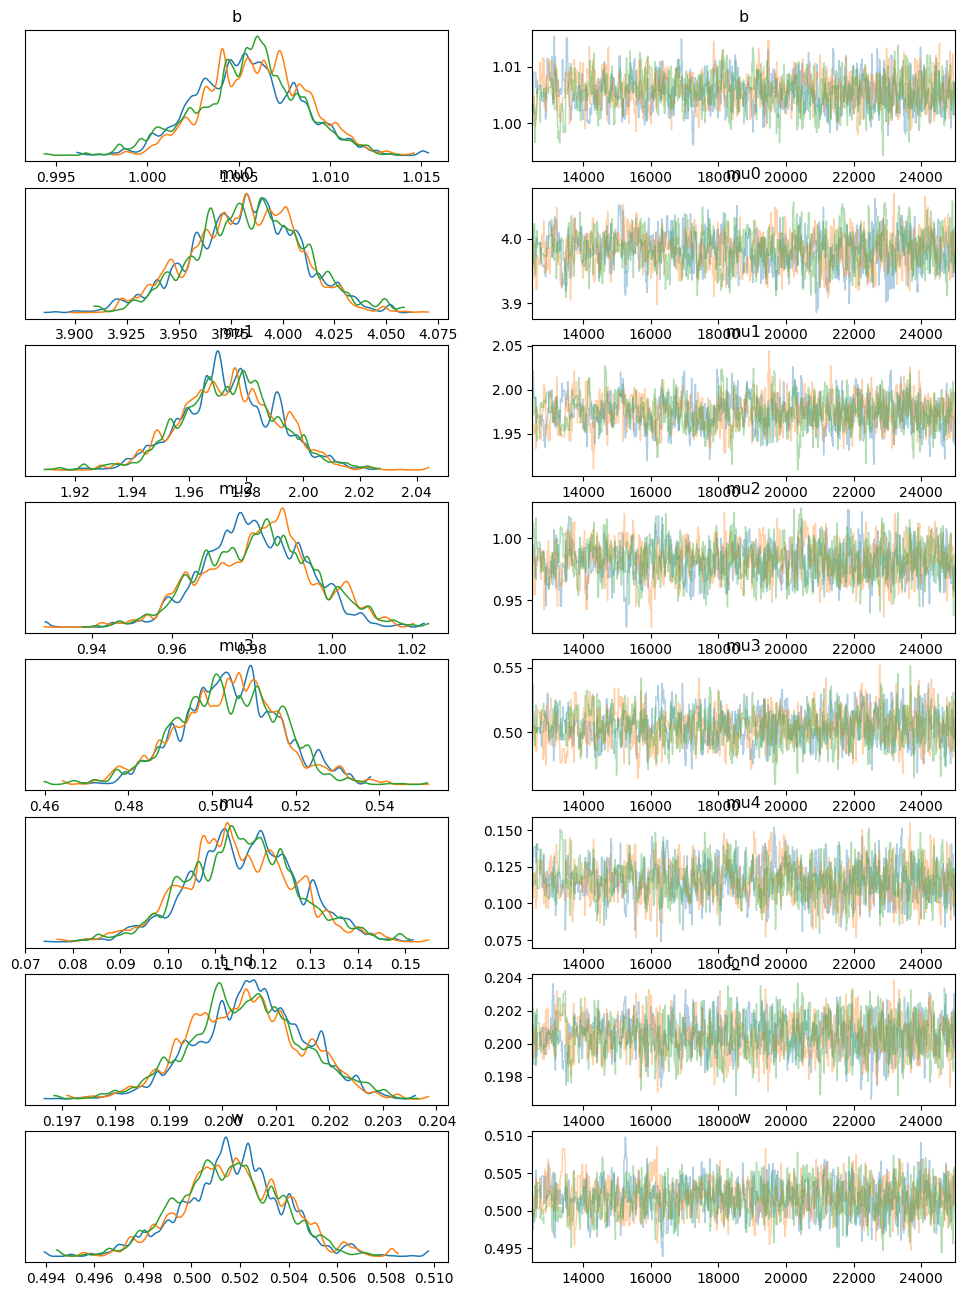

In [76]:
pbp.plot_idata(file_name='simpleDDM', burnin = 12500)

In [95]:
df_simpleddm = pbp.summary(file_name = 'simpleDDM', burnin = 12500)
df_simpleddm

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
b,1.006,0.003,1.000,1.011,0.000,0.000,636.0,1110.0,1.01
mu0,3.983,0.026,3.935,4.031,0.001,0.001,612.0,1094.0,1.01
mu1,1.974,0.017,1.945,2.007,0.001,0.000,631.0,1139.0,1.00
mu2,0.982,0.014,0.957,1.006,0.001,0.000,628.0,947.0,1.00
mu3,0.504,0.012,0.482,0.528,0.000,0.000,741.0,1111.0,1.01
mu4,0.116,0.012,0.094,0.138,0.000,0.000,627.0,825.0,1.00
t_nd,0.200,0.001,0.199,0.202,0.000,0.000,749.0,1344.0,1.00
w,0.502,0.002,0.498,0.505,0.000,0.000,743.0,970.0,1.00


In [79]:
variables = ["b", "mu0", "mu1", "mu2", "mu3", "mu4", "t_nd", "w"]
means_dict = {var: idata.posterior[var].mean(dim=["chain", "draw"]).item() for var in variables}

# Rename 't_nd' to 'tnd'
means_dict['tnd'] = means_dict.pop('t_nd')
print(means_dict)

{'b': 0.9952121629244155, 'mu0': 3.77991396569943, 'mu1': 1.8749546481940875, 'mu2': 0.9356293113122526, 'mu3': 0.4807345183477393, 'mu4': 0.0926823839583116, 'w': 0.5123856204113811, 'tnd': 0.20498726196441752}


In [83]:
# Create 5 new phi_n dictionaries from means_dict. b, tnd, w are the same for all phi_n dictionaries. mu0, mu1, mu2, mu3, mu4 are different for each phi_n dictionary. name nem phi_4_0, phi_2_0, phi_1_0, phi_0_5, phi_0_1.
phi_4_0_simpleddm = {
    "w": means_dict['w'],
    "tnd": means_dict['tnd'],
    "b": means_dict['b'],
    "mu": means_dict['mu0'],
}

phi_2_0_simpleddm = {
    "w": means_dict['w'],
    "tnd": means_dict['tnd'],
    "b": means_dict['b'],
    "mu": means_dict['mu1'],
}

phi_1_0_simpleddm = {
    "w": means_dict['w'],
    "tnd": means_dict['tnd'],
    "b": means_dict['b'],
    "mu": means_dict['mu2'],
}

phi_0_5_simpleddm = {
    "w": means_dict['w'],
    "tnd": means_dict['tnd'],
    "b": means_dict['b'],
    "mu": means_dict['mu3'],
}

phi_0_1_simpleddm = {
    "w": means_dict['w'],
    "tnd": means_dict['tnd'],
    "b": means_dict['b'],
    "mu": means_dict['mu4'],
}

In [84]:
ll_fitted_simpleddm_original_4_0 = pbp.loglikelihood(simpleDDM, phi_4_0_simpleddm, rt={'rt_upper': rts_original_4_0_upper, 'rt_lower': -1 * rts_original_4_0_lower})
ll_fitted_simpleddm_rnn_4_0 = pbp.loglikelihood(simpleDDM, phi_4_0_simpleddm, rt={'rt_upper': rts_rnn_4_0_upper, 'rt_lower': -1 * rts_rnn_4_0_lower})
ll_fitted_simpleddm_sindy_4_0 = pbp.loglikelihood(simpleDDM, phi_4_0_simpleddm, rt={'rt_upper': rts_sindy_4_0_upper, 'rt_lower': -1 * rts_sindy_4_0_lower})
print(f'v = 4.0 \n LL - Original: {ll_fitted_simpleddm_original_4_0} \n LL - RNN: {ll_fitted_simpleddm_rnn_4_0} \n LL - SINDy: {ll_fitted_simpleddm_sindy_4_0}')

v = 4.0 
 LL - Original: 6653.079513985459 
 LL - RNN: 7047.713650276052 
 LL - SINDy: 6879.032782649884


In [85]:
ll_fitted_simpleddm_original_2_0 = pbp.loglikelihood(simpleDDM, phi_2_0_simpleddm, rt={'rt_upper': rts_original_2_0_upper, 'rt_lower': -1 * rts_original_2_0_lower})
ll_fitted_simpleddm_rnn_2_0 = pbp.loglikelihood(simpleDDM, phi_2_0_simpleddm, rt={'rt_upper': rts_rnn_2_0_upper, 'rt_lower': -1 * rts_rnn_2_0_lower})
ll_fitted_simpleddm_sindy_2_0 = pbp.loglikelihood(simpleDDM, phi_2_0_simpleddm, rt={'rt_upper': rts_sindy_2_0_upper, 'rt_lower': -1 * rts_sindy_2_0_lower})
print(f'v = 2.0 \n LL - Original: {ll_fitted_simpleddm_original_2_0} \n LL - RNN: {ll_fitted_simpleddm_rnn_2_0} \n LL - SINDy: {ll_fitted_simpleddm_sindy_2_0}')

v = 2.0 
 LL - Original: -2098.4858083952004 
 LL - RNN: -1183.411689911216 
 LL - SINDy: -1537.0539583490745


In [86]:
ll_fitted_simpleddm_original_1_0 = pbp.loglikelihood(simpleDDM, phi_1_0_simpleddm, rt={'rt_upper': rts_original_1_0_upper, 'rt_lower': -1 * rts_original_1_0_lower})
ll_fitted_simpleddm_rnn_1_0 = pbp.loglikelihood(simpleDDM, phi_1_0_simpleddm, rt={'rt_upper': rts_rnn_1_0_upper, 'rt_lower': -1 * rts_rnn_1_0_lower})
ll_fitted_simpleddm_sindy_1_0 = pbp.loglikelihood(simpleDDM, phi_1_0_simpleddm, rt={'rt_upper': rts_sindy_1_0_upper, 'rt_lower': -1 * rts_sindy_1_0_lower})
print(f'v = 1.0 \n LL - Original: {ll_fitted_simpleddm_original_1_0} \n LL - RNN: {ll_fitted_simpleddm_rnn_1_0} \n LL - SINDy: {ll_fitted_simpleddm_sindy_1_0}')

v = 1.0 
 LL - Original: -16639.539103249845 
 LL - RNN: -15978.809096085184 
 LL - SINDy: -14041.257698028276


In [87]:
ll_fitted_simpleddm_original_0_5 = pbp.loglikelihood(simpleDDM, phi_0_5_simpleddm, rt={'rt_upper': rts_original_0_5_upper, 'rt_lower': -1 * rts_original_0_5_lower})
ll_fitted_simpleddm_rnn_0_5 = pbp.loglikelihood(simpleDDM, phi_0_5_simpleddm, rt={'rt_upper': rts_rnn_0_5_upper, 'rt_lower': -1 * rts_rnn_0_5_lower})
ll_fitted_simpleddm_sindy_0_5 = pbp.loglikelihood(simpleDDM, phi_0_5_simpleddm, rt={'rt_upper': rts_sindy_0_5_upper, 'rt_lower': -1 * rts_sindy_0_5_lower})
print(f'v = 0.5 \n LL - Original: {ll_fitted_simpleddm_original_0_5} \n LL - RNN: {ll_fitted_simpleddm_rnn_0_5} \n LL - SINDy: {ll_fitted_simpleddm_sindy_0_5}')

v = 0.5 
 LL - Original: -31506.300405615904 
 LL - RNN: -30607.794685326386 
 LL - SINDy: -30335.811246080586


In [88]:
ll_fitted_simpleddm_original_0_1 = pbp.loglikelihood(simpleDDM, phi_0_1_simpleddm, rt={'rt_upper': rts_original_0_1_upper, 'rt_lower': -1 * rts_original_0_1_lower})
ll_fitted_simpleddm_rnn_0_1 = pbp.loglikelihood(simpleDDM, phi_0_1_simpleddm, rt={'rt_upper': rts_rnn_0_1_upper, 'rt_lower': -1 * rts_rnn_0_1_lower})
ll_fitted_simpleddm_sindy_0_1 = pbp.loglikelihood(simpleDDM, phi_0_1_simpleddm, rt={'rt_upper': rts_sindy_0_1_upper, 'rt_lower': -1 * rts_sindy_0_1_lower})
print(f'v = 0.1 \n LL - Original: {ll_fitted_simpleddm_original_0_1} \n LL - RNN: {ll_fitted_simpleddm_rnn_0_1} \n LL - SINDy: {ll_fitted_simpleddm_sindy_0_1}')

v = 0.1 
 LL - Original: -48330.082468291796 
 LL - RNN: -47282.24790606476 
 LL - SINDy: -47024.46151090611


### Fit FullDDM to Original Data

In [90]:
fullDDM = pbp.fullDDM()

In [91]:
p = {
    'p_tnd': 'Uniform("tnd", lower = 0.0, upper = 1.0)',
    'p_sd_tnd': 'Uniform("sd_tnd", lower = 0.001, upper = 0.25)',
    'p_w': 'Uniform("w", lower = 0.25, upper = 0.75)',
    'p_sd_w': 'Uniform("sd_w", lower = 0.01, upper = 0.99)',
    'p_mu0': 'Uniform("mu0", lower = -5.0, upper = 5.0)',
    'p_sd_mu0': 'Uniform("sd_mu0", lower = 0.001, upper = 5.0)',
    'p_mu1': 'Uniform("mu1", lower = -5.0, upper = 5.0)',
    'p_sd_mu1': 'Uniform("sd_mu1", lower = 0.001, upper = 5.0)',
    'p_mu2': 'Uniform("mu2", lower = -5.0, upper = 5.0)',
    'p_sd_mu2': 'Uniform("sd_mu2", lower = 0.001, upper = 5.0)',
    'p_mu3': 'Uniform("mu3", lower = -5.0, upper = 5.0)',
    'p_sd_mu3': 'Uniform("sd_mu3", lower = 0.001, upper = 5.0)',
    'p_mu4': 'Uniform("mu4", lower = -5.0, upper = 5.0)',
    'p_sd_mu4': 'Uniform("sd_mu4", lower = 0.001, upper = 5.0)',
    'p_b': 'Uniform("b", lower = 0.1, upper = 2.5)'
}

c0 = {
    'rt': {'rt_upper': rts_original_4_0_upper, 'rt_lower': rts_original_4_0_lower},
    'tnd': 'p_tnd',
    'sd_tnd': 'p_sd_tnd',
    'w': 'p_w',
    'sd_w': 'p_sd_w',
    'mu': 'p_mu0',
    'sd_mu': 'p_sd_mu0',
    'b': 'p_b'
}

c1 = {
    'rt': {'rt_upper': rts_original_2_0_upper, 'rt_lower': rts_original_2_0_lower},
    'tnd': 'p_tnd',
    'sd_tnd': 'p_sd_tnd',
    'w': 'p_w',
    'sd_w': 'p_sd_w',
    'mu': 'p_mu1',
    'sd_mu': 'p_sd_mu1',
    'b': 'p_b'
}

c2 = {
    'rt': {'rt_upper': rts_original_1_0_upper, 'rt_lower': rts_original_1_0_lower},
    'tnd': 'p_tnd',
    'sd_tnd': 'p_sd_tnd',
    'w': 'p_w',
    'sd_w': 'p_sd_w',
    'mu': 'p_mu2',
    'sd_mu': 'p_sd_mu2',
    'b': 'p_b'
}

c3 = {
    'rt': {'rt_upper': rts_original_0_5_upper, 'rt_lower': rts_original_0_5_lower},
    'tnd': 'p_tnd',
    'sd_tnd': 'p_sd_tnd',
    'w': 'p_w',
    'sd_w': 'p_sd_w',
    'mu': 'p_mu3',
    'sd_mu': 'p_sd_mu3',
    'b': 'p_b'
}

c4 = {
    'rt': {'rt_upper': rts_original_0_1_upper, 'rt_lower': rts_original_0_1_lower},
    'tnd': 'p_tnd',
    'sd_tnd': 'p_sd_tnd',
    'w': 'p_w',
    'sd_w': 'p_sd_w',
    'mu': 'p_mu4',
    'sd_mu': 'p_sd_mu4',
    'b': 'p_b'
}

c = {0: c0, 1: c1, 2: c2, 3: c3, 4: c4}

idata_fullddm = pbp.inference(
    model=fullDDM,
    priors=p,
    conditions=c,
    samples=25000,
    chains=3,
    cores=3,
    file_name='DDM'
)

Multiprocess sampling (3 chains in 3 jobs)
DEMetropolisZ: [tnd, sd_tnd, w, sd_w, mu0, sd_mu0, mu1, sd_mu1, mu2, sd_mu2, mu3, sd_mu3, mu4, sd_mu4, b]


Output()

/Users/imtezcan/.pyenv/versions/autossm-2afc/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:1228: RuntimeWarning: overflow encountered in exp
  "accept": np.exp(accept),
/Users/imtezcan/.pyenv/versions/autossm-2afc/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:1228: RuntimeWarning: overflow encountered in exp
  "accept": np.exp(accept),
/Users/imtezcan/.pyenv/versions/autossm-2afc/lib/python3.11/site-packages/pymc/step_methods/metropolis.py:1228: RuntimeWarning: overflow encountered in exp
  "accept": np.exp(accept),
/Users/imtezcan/Repositories/CogSci/Thesis/autossm-2afc/src/ddm/pybeam_simulate/pybeam/precoded/loglike_class.py:85: RuntimeWarning: invalid value encountered in log
  logl = self.likelihood(phi, psi, self.w_dist, self.tnd_dist, self.N_tnd, self.mu_dist, self.N_mu, self.N_deps, self.dt_scale, self.dt_interp_scale, self.dt_interp_overide, self.rtu, self.rtl, self.rt_max)


Sampling 3 chains for 0 tune and 25_000 draw iterations (0 + 75_000 draws total) took 2325 seconds.


array([[<Axes: title={'center': 'b'}>, <Axes: title={'center': 'b'}>],
       [<Axes: title={'center': 'mu0'}>, <Axes: title={'center': 'mu0'}>],
       [<Axes: title={'center': 'mu1'}>, <Axes: title={'center': 'mu1'}>],
       [<Axes: title={'center': 'mu2'}>, <Axes: title={'center': 'mu2'}>],
       [<Axes: title={'center': 'mu3'}>, <Axes: title={'center': 'mu3'}>],
       [<Axes: title={'center': 'mu4'}>, <Axes: title={'center': 'mu4'}>],
       [<Axes: title={'center': 'sd_mu0'}>,
        <Axes: title={'center': 'sd_mu0'}>],
       [<Axes: title={'center': 'sd_mu1'}>,
        <Axes: title={'center': 'sd_mu1'}>],
       [<Axes: title={'center': 'sd_mu2'}>,
        <Axes: title={'center': 'sd_mu2'}>],
       [<Axes: title={'center': 'sd_mu3'}>,
        <Axes: title={'center': 'sd_mu3'}>],
       [<Axes: title={'center': 'sd_mu4'}>,
        <Axes: title={'center': 'sd_mu4'}>],
       [<Axes: title={'center': 'sd_tnd'}>,
        <Axes: title={'center': 'sd_tnd'}>],
       [<Axes: title

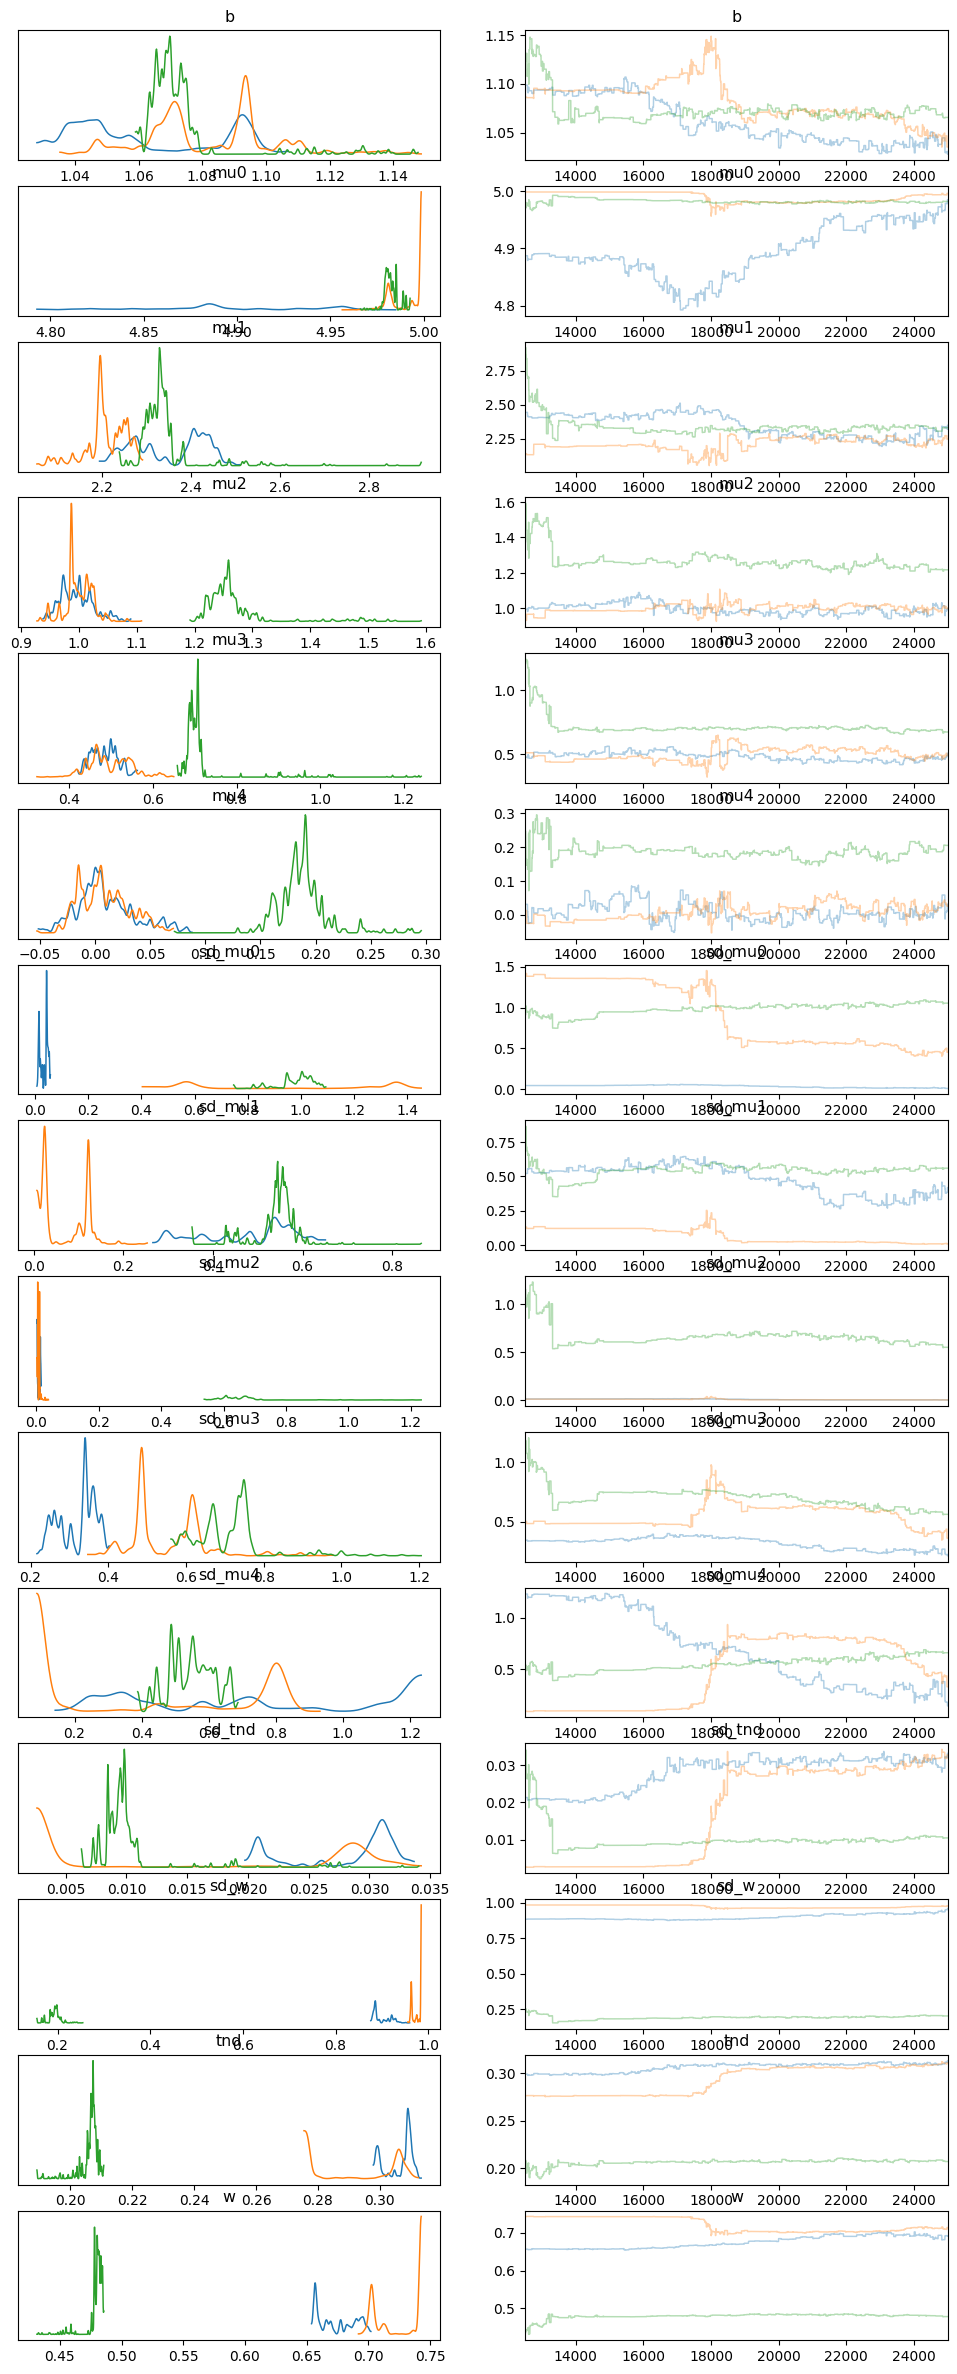

In [92]:
pbp.plot_idata(file_name='DDM', burnin = 12500)

In [94]:
df_fullddm = pbp.summary(file_name = 'DDM', burnin = 12500)
df_fullddm

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
b,1.072,0.021,1.030,1.106,0.010,0.008,5.0,13.0,1.77
mu0,4.955,0.051,4.849,4.999,0.028,0.022,4.0,12.0,2.31
mu1,2.299,0.091,2.160,2.465,0.046,0.036,4.0,14.0,2.30
mu2,1.088,0.132,0.943,1.280,0.074,0.058,4.0,15.0,1.96
mu3,0.565,0.119,0.431,0.715,0.063,0.049,4.0,40.0,2.11
mu4,0.068,0.087,-0.027,0.206,0.049,0.038,4.0,37.0,1.83
sd_mu0,0.642,0.488,0.014,1.360,0.278,0.219,3.0,13.0,3.25
sd_mu1,0.363,0.222,0.008,0.591,0.126,0.099,4.0,12.0,2.22
sd_mu2,0.225,0.313,0.002,0.684,0.178,0.140,4.0,15.0,2.44
sd_mu3,0.526,0.177,0.244,0.759,0.095,0.073,4.0,14.0,2.44


In [97]:
# Convert to means_dict like before but for fullDDM
variables = ["b", "mu0", "sd_mu0", "mu1", "sd_mu1", "mu2", "sd_mu2", "mu3", "sd_mu3", "mu4", "sd_mu4", "tnd", "sd_tnd", "w", "sd_w"]
means_dict_fullddm = {var: idata_fullddm.posterior[var].mean(dim=["chain", "draw"]).item() for var in variables}

In [99]:
# Create 5 new phi_n dictionaries from means_dict_fullddm. b, tnd, w are the same for all phi_n dictionaries. mu0, mu1, mu2, mu3, mu4 and their sd_ variants are different for each phi_n dictionary. name them phi_4_0_fullddm, phi_2_0_fullddm, phi_1_0_fullddm, phi_0_5_fullddm, phi_0_1_fullddm.
phi_4_0_fullddm = {
    "w": means_dict_fullddm['w'],
    "sd_w": means_dict_fullddm['sd_w'],
    "tnd": means_dict_fullddm['tnd'],
    "sd_tnd": means_dict_fullddm['sd_tnd'],
    "b": means_dict_fullddm['b'],
    "mu": means_dict_fullddm['mu0'],
    "sd_mu": means_dict_fullddm['sd_mu0'],
}

phi_2_0_fullddm = {
    "w": means_dict_fullddm['w'],
    "sd_w": means_dict_fullddm['sd_w'],
    "tnd": means_dict_fullddm['tnd'],
    "sd_tnd": means_dict_fullddm['sd_tnd'],
    "b": means_dict_fullddm['b'],
    "mu": means_dict_fullddm['mu1'],
    "sd_mu": means_dict_fullddm['sd_mu1'],
}

phi_1_0_fullddm = {
    "w": means_dict_fullddm['w'],
    "sd_w": means_dict_fullddm['sd_w'],
    "tnd": means_dict_fullddm['tnd'],
    "sd_tnd": means_dict_fullddm['sd_tnd'],
    "b": means_dict_fullddm['b'],
    "mu": means_dict_fullddm['mu2'],
    "sd_mu": means_dict_fullddm['sd_mu2'],
}

phi_0_5_fullddm = {
    "w": means_dict_fullddm['w'],
    "sd_w": means_dict_fullddm['sd_w'],
    "tnd": means_dict_fullddm['tnd'],
    "sd_tnd": means_dict_fullddm['sd_tnd'],
    "b": means_dict_fullddm['b'],
    "mu": means_dict_fullddm['mu3'],
    "sd_mu": means_dict_fullddm['sd_mu3'],
}

phi_0_1_fullddm = {
    "w": means_dict_fullddm['w'],
    "sd_w": means_dict_fullddm['sd_w'],
    "tnd": means_dict_fullddm['tnd'],
    "sd_tnd": means_dict_fullddm['sd_tnd'],
    "b": means_dict_fullddm['b'],
    "mu": means_dict_fullddm['mu4'],
    "sd_mu": means_dict_fullddm['sd_mu4'],
}

In [101]:
ll_fitted_fullddm_original_4_0 = pbp.loglikelihood(fullDDM, phi_4_0_fullddm, rt={'rt_upper': rts_original_4_0_upper, 'rt_lower': -1 * rts_original_4_0_lower})
ll_fitted_fullddm_rnn_4_0 = pbp.loglikelihood(fullDDM, phi_4_0_fullddm, rt={'rt_upper': rts_rnn_4_0_upper, 'rt_lower': -1 * rts_rnn_4_0_lower})
ll_fitted_fullddm_sindy_4_0 = pbp.loglikelihood(fullDDM, phi_4_0_fullddm, rt={'rt_upper': rts_sindy_4_0_upper, 'rt_lower': -1 * rts_sindy_4_0_lower})
print(f'v = 4.0 \n LL - Original: {ll_fitted_fullddm_original_4_0} \n LL - RNN: {ll_fitted_fullddm_rnn_4_0} \n LL - SINDy: {ll_fitted_fullddm_sindy_4_0}')

ll_fitted_fullddm_original_2_0 = pbp.loglikelihood(fullDDM, phi_2_0_fullddm, rt={'rt_upper': rts_original_2_0_upper, 'rt_lower': -1 * rts_original_2_0_lower})
ll_fitted_fullddm_rnn_2_0 = pbp.loglikelihood(fullDDM, phi_2_0_fullddm, rt={'rt_upper': rts_rnn_2_0_upper, 'rt_lower': -1 * rts_rnn_2_0_lower})
ll_fitted_fullddm_sindy_2_0 = pbp.loglikelihood(fullDDM, phi_2_0_fullddm, rt={'rt_upper': rts_sindy_2_0_upper, 'rt_lower': -1 * rts_sindy_2_0_lower})
print(f'v = 2.0 \n LL - Original: {ll_fitted_fullddm_original_2_0} \n LL - RNN: {ll_fitted_fullddm_rnn_2_0} \n LL - SINDy: {ll_fitted_fullddm_sindy_2_0}')

ll_fitted_fullddm_original_1_0 = pbp.loglikelihood(fullDDM, phi_1_0_fullddm, rt={'rt_upper': rts_original_1_0_upper, 'rt_lower': -1 * rts_original_1_0_lower})
ll_fitted_fullddm_rnn_1_0 = pbp.loglikelihood(fullDDM, phi_1_0_fullddm, rt={'rt_upper': rts_rnn_1_0_upper, 'rt_lower': -1 * rts_rnn_1_0_lower})
ll_fitted_fullddm_sindy_1_0 = pbp.loglikelihood(fullDDM, phi_1_0_fullddm, rt={'rt_upper': rts_sindy_1_0_upper, 'rt_lower': -1 * rts_sindy_1_0_lower})
print(f'v = 1.0 \n LL - Original: {ll_fitted_fullddm_original_1_0} \n LL - RNN: {ll_fitted_fullddm_rnn_1_0} \n LL - SINDy: {ll_fitted_fullddm_sindy_1_0}')

ll_fitted_fullddm_original_0_5 = pbp.loglikelihood(fullDDM, phi_0_5_fullddm, rt={'rt_upper': rts_original_0_5_upper, 'rt_lower': -1 * rts_original_0_5_lower})
ll_fitted_fullddm_rnn_0_5 = pbp.loglikelihood(fullDDM, phi_0_5_fullddm, rt={'rt_upper': rts_rnn_0_5_upper, 'rt_lower': -1 * rts_rnn_0_5_lower})
ll_fitted_fullddm_sindy_0_5 = pbp.loglikelihood(fullDDM, phi_0_5_fullddm, rt={'rt_upper': rts_sindy_0_5_upper, 'rt_lower': -1 * rts_sindy_0_5_lower})
print(f'v = 0.5 \n LL - Original: {ll_fitted_fullddm_original_0_5} \n LL - RNN: {ll_fitted_fullddm_rnn_0_5} \n LL - SINDy: {ll_fitted_fullddm_sindy_0_5}')

ll_fitted_fullddm_original_0_1 = pbp.loglikelihood(fullDDM, phi_0_1_fullddm, rt={'rt_upper': rts_original_0_1_upper, 'rt_lower': -1 * rts_original_0_1_lower})
ll_fitted_fullddm_rnn_0_1 = pbp.loglikelihood(fullDDM, phi_0_1_fullddm, rt={'rt_upper': rts_rnn_0_1_upper, 'rt_lower': -1 * rts_rnn_0_1_lower})
ll_fitted_fullddm_sindy_0_1 = pbp.loglikelihood(fullDDM, phi_0_1_fullddm, rt={'rt_upper': rts_sindy_0_1_upper, 'rt_lower': -1 * rts_sindy_0_1_lower})
print(f'v = 0.1 \n LL - Original: {ll_fitted_fullddm_original_0_1} \n LL - RNN: {ll_fitted_fullddm_rnn_0_1} \n LL - SINDy: {ll_fitted_fullddm_sindy_0_1}')

v = 4.0 
 LL - Original: 5804.705236164891 
 LL - RNN: 6137.86208582052 
 LL - SINDy: 5963.583238031491
v = 2.0 
 LL - Original: -2728.6050813722936 
 LL - RNN: -1451.0883900375509 
 LL - SINDy: -2426.1146388816996
v = 1.0 
 LL - Original: -17285.292411546732 
 LL - RNN: -16120.341865222685 
 LL - SINDy: -14996.620398112393
v = 0.5 
 LL - Original: -32218.29505445871 
 LL - RNN: -31027.850181289537 
 LL - SINDy: -31189.7950503849
v = 0.1 
 LL - Original: -48638.430862713765 
 LL - RNN: -47228.411356399534 
 LL - SINDy: -47402.30671450048


### Simulate new data from fitted models

In [107]:
rt_dict_simpleddm_4_0 = pbp.simulate(N_sims=rts_original_4_0.size, model=simpleDDM, phi=phi_4_0_simpleddm)
rts_simpleddm_4_0_upper = rt_dict_simpleddm_4_0['rt_upper']
rts_simpleddm_4_0_lower = rt_dict_simpleddm_4_0['rt_lower']
rts_simple_ddm_4_0 = np.concatenate([rts_simpleddm_4_0_upper, -1 * rts_simpleddm_4_0_lower])

rt_dict_simpleddm_2_0 = pbp.simulate(N_sims=rts_original_2_0.size, model=simpleDDM, phi=phi_2_0_simpleddm)
rts_simpleddm_2_0_upper = rt_dict_simpleddm_2_0['rt_upper']
rts_simpleddm_2_0_lower = rt_dict_simpleddm_2_0['rt_lower']
rts_simple_ddm_2_0 = np.concatenate([rts_simpleddm_2_0_upper, -1 * rts_simpleddm_2_0_lower])

rt_dict_simpleddm_1_0 = pbp.simulate(N_sims=rts_original_1_0.size, model=simpleDDM, phi=phi_1_0_simpleddm)
rts_simpleddm_1_0_upper = rt_dict_simpleddm_1_0['rt_upper']
rts_simpleddm_1_0_lower = rt_dict_simpleddm_1_0['rt_lower']
rts_simple_ddm_1_0 = np.concatenate([rts_simpleddm_1_0_upper, -1 * rts_simpleddm_1_0_lower])

rt_dict_simpleddm_0_5 = pbp.simulate(N_sims=rts_original_0_5.size, model=simpleDDM, phi=phi_0_5_simpleddm)
rts_simpleddm_0_5_upper = rt_dict_simpleddm_0_5['rt_upper']
rts_simpleddm_0_5_lower = rt_dict_simpleddm_0_5['rt_lower']
rts_simple_ddm_0_5 = np.concatenate([rts_simpleddm_0_5_upper, -1 * rts_simpleddm_0_5_lower])

rt_dict_simpleddm_0_1 = pbp.simulate(N_sims=rts_original_0_1.size, model=simpleDDM, phi=phi_0_1_simpleddm)
rts_simpleddm_0_1_upper = rt_dict_simpleddm_0_1['rt_upper']
rts_simpleddm_0_1_lower = rt_dict_simpleddm_0_1['rt_lower']
rts_simple_ddm_0_1 = np.concatenate([rts_simpleddm_0_1_upper, -1 * rts_simpleddm_0_1_lower])

In [108]:
rt_dict_fullddm_4_0 = pbp.simulate(N_sims=rts_original_4_0.size, model=fullDDM, phi=phi_4_0_fullddm)
rts_fullddm_4_0_upper = rt_dict_fullddm_4_0['rt_upper']
rts_fullddm_4_0_lower = rt_dict_fullddm_4_0['rt_lower']
rts_fullddm_4_0 = np.concatenate([rts_fullddm_4_0_upper, -1 * rts_fullddm_4_0_lower])

rt_dict_fullddm_2_0 = pbp.simulate(N_sims=rts_original_2_0.size, model=fullDDM, phi=phi_2_0_fullddm)
rts_fullddm_2_0_upper = rt_dict_fullddm_2_0['rt_upper']
rts_fullddm_2_0_lower = rt_dict_fullddm_2_0['rt_lower']
rts_fullddm_2_0 = np.concatenate([rts_fullddm_2_0_upper, -1 * rts_fullddm_2_0_lower])

rt_dict_fullddm_1_0 = pbp.simulate(N_sims=rts_original_1_0.size, model=fullDDM, phi=phi_1_0_fullddm)
rts_fullddm_1_0_upper = rt_dict_fullddm_1_0['rt_upper']
rts_fullddm_1_0_lower = rt_dict_fullddm_1_0['rt_lower']
rts_fullddm_1_0 = np.concatenate([rts_fullddm_1_0_upper, -1 * rts_fullddm_1_0_lower])

rt_dict_fullddm_0_5 = pbp.simulate(N_sims=rts_original_0_5.size, model=fullDDM, phi=phi_0_5_fullddm)
rts_fullddm_0_5_upper = rt_dict_fullddm_0_5['rt_upper']
rts_fullddm_0_5_lower = rt_dict_fullddm_0_5['rt_lower']
rts_fullddm_0_5 = np.concatenate([rts_fullddm_0_5_upper, -1 * rts_fullddm_0_5_lower])

rt_dict_fullddm_0_1 = pbp.simulate(N_sims=rts_original_0_1.size, model=fullDDM, phi=phi_0_1_fullddm)
rts_fullddm_0_1_upper = rt_dict_fullddm_0_1['rt_upper']
rts_fullddm_0_1_lower = rt_dict_fullddm_0_1['rt_lower']
rts_fullddm_0_1 = np.concatenate([rts_fullddm_0_1_upper, -1 * rts_fullddm_0_1_lower])

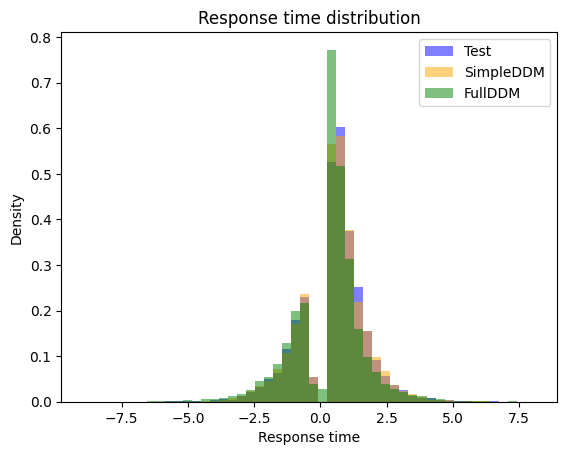

In [110]:
rt_dict = {
    'rts': [rts_original_0_5, rts_simple_ddm_0_5, rts_fullddm_0_5],
    'labels': ['Test', 'SimpleDDM', 'FullDDM'],
    'colors': ['blue', 'orange', 'green']
}

fig, ax = plt.subplots()
plot_rts_multi(ax, rt_dict)

plt.show()
plt.close()

### Fit Kernel Density Estimation to each RT set and compare log-likelihoods against each other

For each drift rate, we fit KDEs to each RT set and then compare how well all RTs score against all KDEs.

First, we do cross-validation to find the best bandwidth and kernel for the KDEs.

In [111]:
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KernelDensity

params = {'bandwidth': np.logspace(-3, 1, 30), 'kernel': ['gaussian', 'tophat', 'epanechnikov', 'exponential', 'linear']}
grid = GridSearchCV(KernelDensity(),
                   params,
                   cv=KFold(n_splits=5, shuffle=True, random_state=42))
grid.fit(rts_original_4_0)
bandwidth_4_0 = grid.best_params_['bandwidth']
kernel_4_0 = grid.best_params_['kernel']
print(f'v = 4.0 - Best bandwidth: {bandwidth_4_0} Best kernel: {kernel_4_0}')

v = 4.0 - Best bandwidth: 0.01268961003167922 Best kernel: exponential


/Users/imtezcan/.pyenv/versions/autossm-2afc/lib/python3.11/site-packages/sklearn/model_selection/_search.py:1114: RuntimeWarning: invalid value encountered in subtract
  (array - array_means[:, np.newaxis]) ** 2, axis=1, weights=weights


In [114]:
import seaborn as sns

def get_lls_multi(rt_dict, bandwidth='scott', spacing=1000, bins=50, kernel='gaussian'):
    n_sets = len(rt_dict['rts'])
    kdes = []

    # Fit KDEs for each RT set
    for rts in rt_dict['rts']:
        kde = KernelDensity(bandwidth=bandwidth, kernel=kernel).fit(rts.reshape(-1, 1))
        kdes.append(kde)

    # Calculate log-likelihoods matrix
    ll_matrix = np.zeros((n_sets, n_sets))
    for i in range(n_sets):
        for j in range(n_sets):
            # Score RT set i against KDE j
            ll_matrix[i, j] = kdes[j].score(rt_dict['rts'][i].reshape(-1, 1)) / rt_dict['rts'][i].shape[0]

    # Plotting
    # KDE visualization
    plt.figure(figsize=(10, 6))

    # Find global min and max for x_grid
    min_val = min(rt.min() for rt in rt_dict['rts'])
    max_val = max(rt.max() for rt in rt_dict['rts'])
    x_grid = np.linspace(min_val, max_val, spacing)

    # Plot histograms and KDEs
    for i, (rts, label) in enumerate(zip(rt_dict['rts'], rt_dict['labels'])):
        plt.hist(rts, bins=bins, density=True, alpha=0.5, label=f'{label} (hist)')
        pdf = np.exp(kdes[i].score_samples(x_grid.reshape(-1, 1)))
        plt.plot(x_grid, pdf, '-', label=f'{label} (KDE)')

    plt.legend()
    plt.xlabel('Response Time')
    plt.ylabel('Density')
    plt.title('KDE of Response Time Distributions')
    plt.show()

    # Log-likelihood heatmap
    plt.figure(figsize=(8, 6))
    ax = sns.heatmap(ll_matrix, annot=True, fmt=".2f", cmap="Blues",
                     cbar_kws={'label': 'Log-Likelihood'})
    ax.set_xticklabels(rt_dict['labels'])
    ax.set_yticklabels(rt_dict['labels'], rotation=0)
    plt.xlabel('Response Times')
    plt.ylabel('Kernel Density Estimators')
    plt.title('Log-Likelihood Heatmap')
    plt.show()

    return ll_matrix

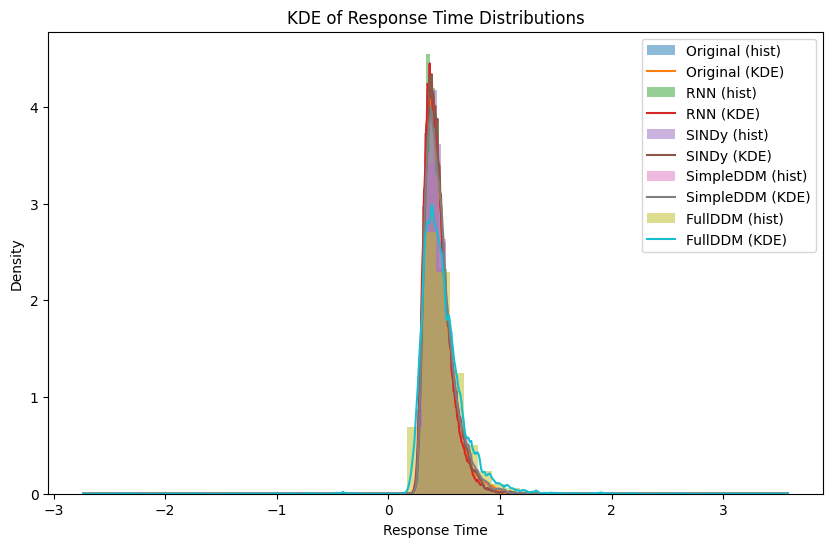

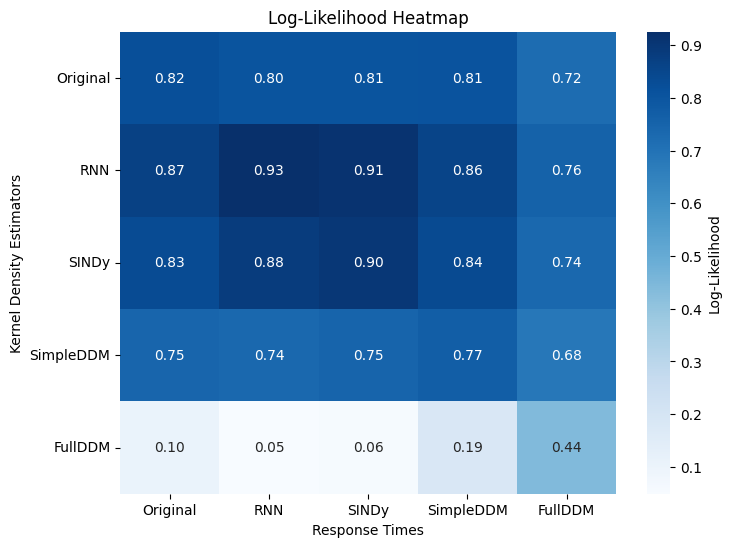

array([[0.82102752, 0.80431413, 0.8054566 , 0.80753611, 0.72014278],
       [0.86755165, 0.92531553, 0.91463774, 0.85916921, 0.75744604],
       [0.83483537, 0.88203715, 0.89917439, 0.83759677, 0.73532545],
       [0.74656664, 0.73520462, 0.7476831 , 0.76997822, 0.68331642],
       [0.10410578, 0.04901884, 0.05761778, 0.18571449, 0.43982056]])

In [116]:
ll_matrix_4_0 = get_lls_multi({"rts": [rts_original_4_0, rts_rnn_4_0, rts_sindy_4_0,
                rts_simple_ddm_4_0, rts_fullddm_4_0],
               "labels": ['Original', 'RNN', 'SINDy', 'SimpleDDM', 'FullDDM']},
              bandwidth=bandwidth_4_0,
              kernel=kernel_4_0)

In [117]:
grid = GridSearchCV(KernelDensity(),
                   params,
                   cv=KFold(n_splits=5, shuffle=True, random_state=42))
grid.fit(rts_original_2_0)
bandwidth_2_0 = grid.best_params_['bandwidth']
kernel_2_0 = grid.best_params_['kernel']
print(f'v = 2.0 - Best bandwidth: {bandwidth_2_0} Best kernel: {kernel_2_0}')

v = 2.0 - Best bandwidth: 0.02395026619987486 Best kernel: exponential


/Users/imtezcan/.pyenv/versions/autossm-2afc/lib/python3.11/site-packages/sklearn/model_selection/_search.py:1114: RuntimeWarning: invalid value encountered in subtract
  (array - array_means[:, np.newaxis]) ** 2, axis=1, weights=weights


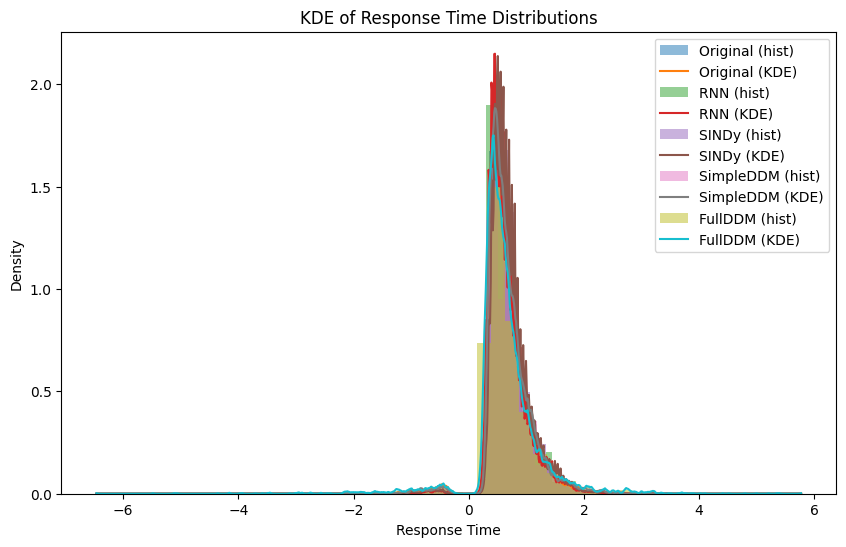

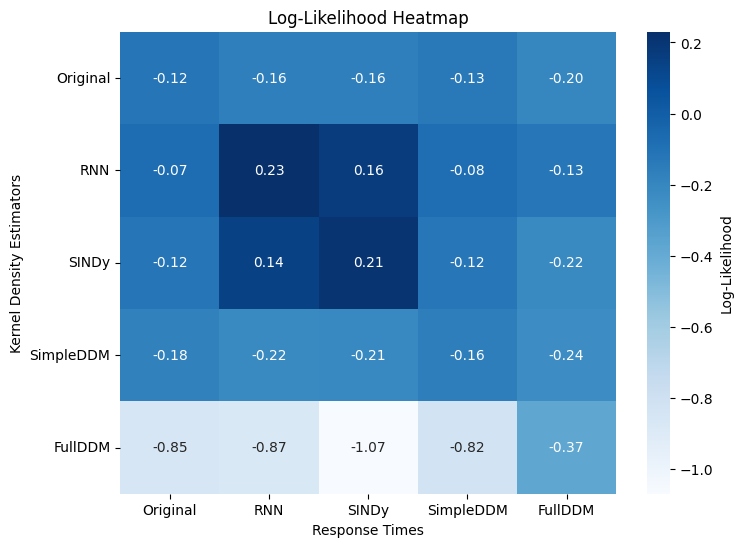

array([[-0.11911822, -0.16490563, -0.16402332, -0.13134127, -0.1987736 ],
       [-0.07490901,  0.23019305,  0.16490683, -0.08183261, -0.12818363],
       [-0.11957172,  0.14310998,  0.20612799, -0.12149661, -0.22180061],
       [-0.17587309, -0.2200232 , -0.20980786, -0.15818937, -0.23547674],
       [-0.85241487, -0.87498913, -1.07001143, -0.82335691, -0.37197699]])

In [118]:
ll_matrix_2_0 = get_lls_multi({"rts": [rts_original_2_0, rts_rnn_2_0, rts_sindy_2_0,
                rts_simple_ddm_2_0, rts_fullddm_2_0],
               "labels": ['Original', 'RNN', 'SINDy', 'SimpleDDM', 'FullDDM']},
              bandwidth=bandwidth_2_0,
              kernel=kernel_2_0)

In [119]:
grid = GridSearchCV(KernelDensity(),
                   params,
                   cv=KFold(n_splits=5, shuffle=True, random_state=42))
grid.fit(rts_original_1_0)
bandwidth_1_0 = grid.best_params_['bandwidth']
kernel_1_0 = grid.best_params_['kernel']
print(f'v = 1.0 - Best bandwidth: {bandwidth_1_0} Best kernel: {kernel_1_0}')

v = 1.0 - Best bandwidth: 0.03290344562312668 Best kernel: exponential


/Users/imtezcan/.pyenv/versions/autossm-2afc/lib/python3.11/site-packages/sklearn/model_selection/_search.py:1114: RuntimeWarning: invalid value encountered in subtract
  (array - array_means[:, np.newaxis]) ** 2, axis=1, weights=weights


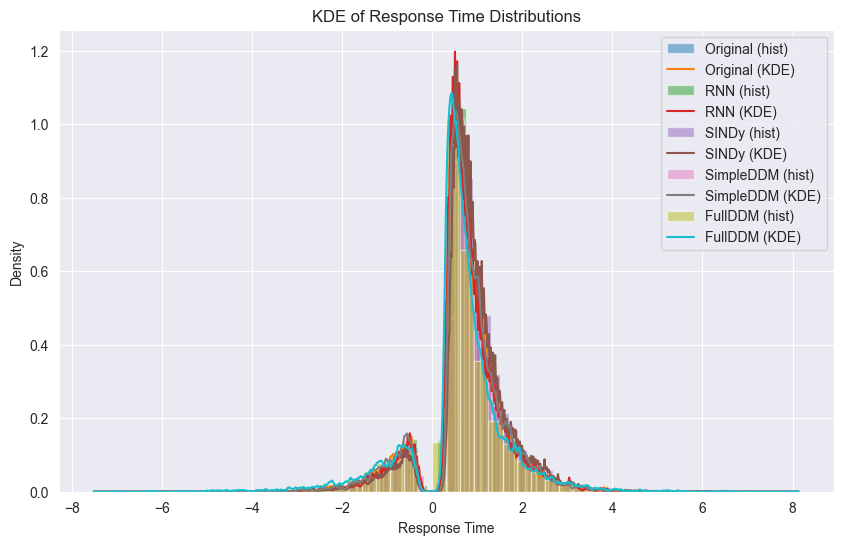

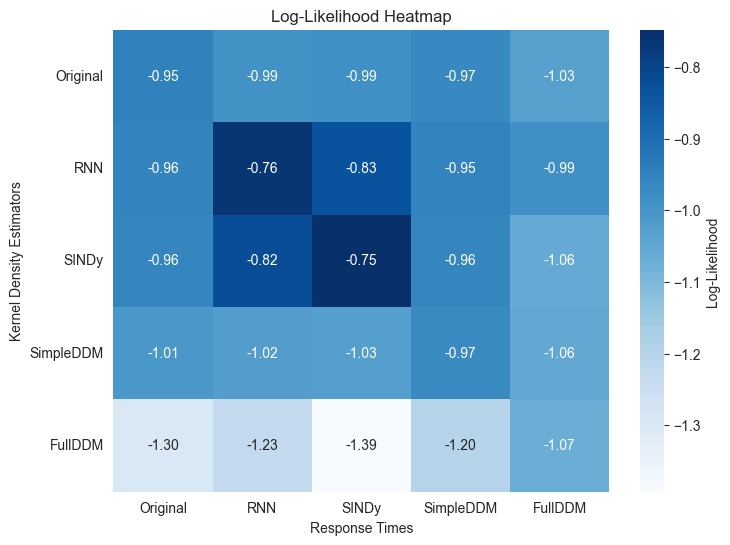

array([[-0.94759116, -0.99022422, -0.9872939 , -0.96540439, -1.03020214],
       [-0.95519916, -0.76194923, -0.83303191, -0.95285929, -0.98545452],
       [-0.95885589, -0.81904936, -0.74824811, -0.9575644 , -1.05935008],
       [-1.00595127, -1.02045502, -1.02576577, -0.97179474, -1.05503762],
       [-1.2959354 , -1.22642357, -1.39273425, -1.19701189, -1.07009181]])

In [120]:
ll_matrix_1_0 = get_lls_multi({"rts": [rts_original_1_0, rts_rnn_1_0, rts_sindy_1_0,
                rts_simple_ddm_1_0, rts_fullddm_1_0],
               "labels": ['Original', 'RNN', 'SINDy', 'SimpleDDM', 'FullDDM']},
              bandwidth=bandwidth_1_0,
              kernel=kernel_1_0)

In [121]:
grid = GridSearchCV(KernelDensity(),
                   params,
                   cv=KFold(n_splits=5, shuffle=True, random_state=42))
grid.fit(rts_original_0_5)
bandwidth_0_5 = grid.best_params_['bandwidth']
kernel_0_5 = grid.best_params_['kernel']
print(f'v = 0.5 - Best bandwidth: {bandwidth_0_5} Best kernel: {kernel_0_5}')

v = 0.5 - Best bandwidth: 0.04520353656360243 Best kernel: exponential


/Users/imtezcan/.pyenv/versions/autossm-2afc/lib/python3.11/site-packages/sklearn/model_selection/_search.py:1114: RuntimeWarning: invalid value encountered in subtract
  (array - array_means[:, np.newaxis]) ** 2, axis=1, weights=weights


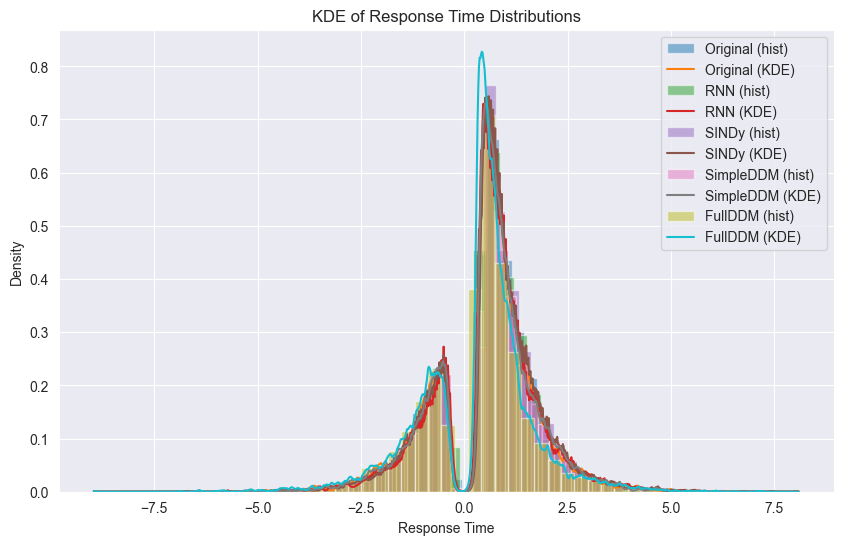

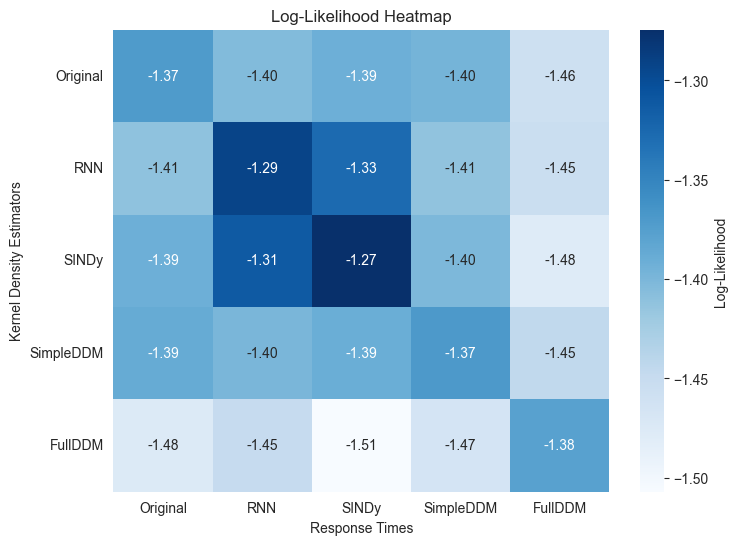

array([[-1.37095707, -1.40413013, -1.39254688, -1.39644537, -1.45736208],
       [-1.4114425 , -1.29197099, -1.32697071, -1.41198853, -1.45348145],
       [-1.39250463, -1.311888  , -1.2744774 , -1.40086803, -1.47712217],
       [-1.38798876, -1.39917387, -1.39059371, -1.36957814, -1.44511933],
       [-1.47605409, -1.44864937, -1.50702911, -1.46544995, -1.37801797]])

In [122]:
ll_matrix_0_5 = get_lls_multi({"rts": [rts_original_0_5, rts_rnn_0_5, rts_sindy_0_5,
                rts_simple_ddm_0_5, rts_fullddm_0_5],
               "labels": ['Original', 'RNN', 'SINDy', 'SimpleDDM', 'FullDDM']},
              bandwidth=bandwidth_0_5,
              kernel=kernel_0_5)

In [123]:
grid = GridSearchCV(KernelDensity(),
                   params,
                   cv=KFold(n_splits=5, shuffle=True, random_state=42))
grid.fit(rts_original_0_1)
bandwidth_0_1 = grid.best_params_['bandwidth']
kernel_0_1 = grid.best_params_['kernel']
print(f'v = 0.1 - Best bandwidth: {bandwidth_0_1} Best kernel: {kernel_0_1}')

v = 0.1 - Best bandwidth: 0.04520353656360243 Best kernel: exponential


/Users/imtezcan/.pyenv/versions/autossm-2afc/lib/python3.11/site-packages/sklearn/model_selection/_search.py:1114: RuntimeWarning: invalid value encountered in subtract
  (array - array_means[:, np.newaxis]) ** 2, axis=1, weights=weights


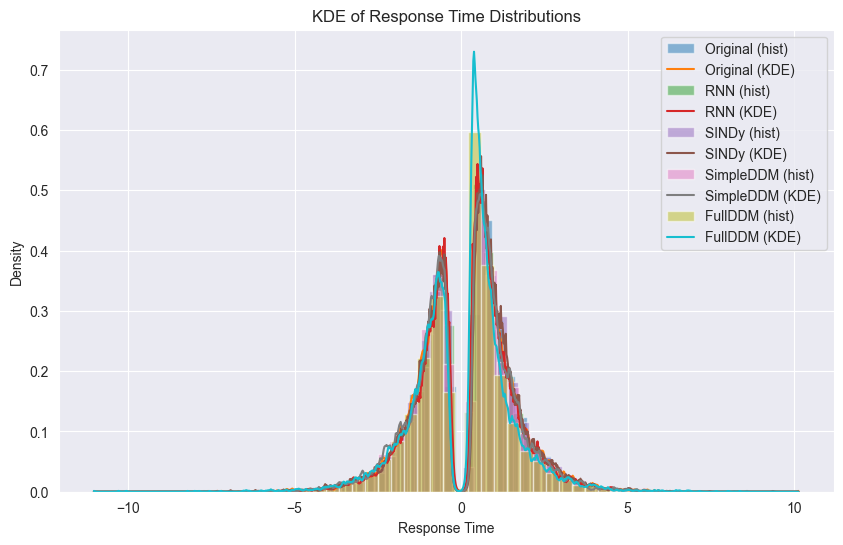

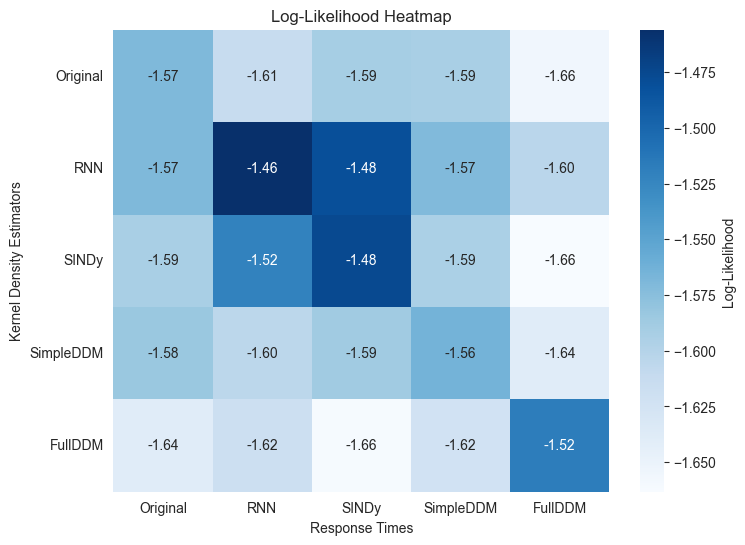

array([[-1.56938527, -1.61256204, -1.59039981, -1.59269802, -1.65517292],
       [-1.56958115, -1.45597295, -1.4807793 , -1.57075713, -1.6041248 ],
       [-1.59234214, -1.52137419, -1.47620019, -1.59388561, -1.66324499],
       [-1.58355921, -1.60416232, -1.58764513, -1.56372156, -1.63944485],
       [-1.6394243 , -1.61747574, -1.66105227, -1.62311027, -1.51684835]])

In [124]:
ll_matrix_0_1 = get_lls_multi({"rts": [rts_original_0_1, rts_rnn_0_1, rts_sindy_0_1,
                rts_simple_ddm_0_1, rts_fullddm_0_1],
               "labels": ['Original', 'RNN', 'SINDy', 'SimpleDDM', 'FullDDM']},
              bandwidth=bandwidth_0_1,
              kernel=kernel_0_1)

## Model Comparison

For each drift rate, we fit a single KDE and score each model's performance against it. We do this for 10 times for each model. We then compare the log-likelihoods of each model in a box plot.

### v = 4.0

In [130]:
n_trials = 10
n_sims = rts_original_4_0.size

all_rts_original_4_0 = []
all_rts_rnn_4_0 = []
all_rts_sindy_4_0 = []
all_rts_simple_ddm_4_0 = []
all_rts_fullddm_4_0 = []

lls_original_4_0 = []
lls_rnn_4_0 = []
lls_sindy_4_0 = []
lls_simple_ddm_4_0 = []
lls_fullddm_4_0 = []

kde_test = KernelDensity(bandwidth=bandwidth_4_0, kernel=kernel_4_0).fit(rts_original_4_0)

for i in range(n_trials):
    obs, _ = pbc.simulate(n_sims, f"../../{config_4_0['simulation_params']['path_pybeam_model']}", phi_4_0, get_traces=True)

    rts_original = np.concatenate([obs['rt_upper'], -1 * obs['rt_lower']])
    rts_original = np.expand_dims(rts_original, axis=1)
    all_rts_original_4_0.append(rts_original)
    lls_original_4_0.append(kde_test.score(rts_original))

    rts_rnn, traces, dt = rnn_regressor_4_0.predict(np.zeros(n_sims))
    rts_rnn = rts_rnn.reshape(-1, 1)
    all_rts_rnn_4_0.append(rts_rnn)
    lls_rnn_4_0.append(kde_test.score(rts_rnn))

    v_init, D_init = traces['drift'][0][0]
    rts_sindy = sindy_predict(sindy_regressor_4_0.sindy, initial_v=v_init, initial_D=D_init, b=rnn_regressor_4_0.rnn.threshold.item(), n_sims=n_sims, dt=dt[0])
    rts_sindy = np.array(rts_sindy).reshape(-1, 1)
    all_rts_sindy_4_0.append(rts_sindy)
    lls_sindy_4_0.append(kde_test.score(rts_sindy))

    obs = pbp.simulate(N_sims=rts_original_4_0.size, model=simpleDDM, phi=phi_4_0_simpleddm)
    rts_simpleddm_upper = obs['rt_upper']
    rts_simpleddm_lower = obs['rt_lower']
    rts_simpleddm = np.concatenate([rts_simpleddm_upper, -1 * rts_simpleddm_lower]).reshape(-1, 1)
    all_rts_simple_ddm_4_0.append(rts_simpleddm)
    lls_simple_ddm_4_0.append(kde_test.score(rts_simpleddm))

    obs = pbp.simulate(N_sims=rts_original_4_0.size, model=fullDDM, phi=phi_4_0_fullddm)
    rts_fullddm_upper = obs['rt_upper']
    rts_fullddm_lower = obs['rt_lower']
    rts_fullddm = np.concatenate([rts_fullddm_upper, -1 * rts_fullddm_lower]).reshape(-1, 1)
    all_rts_fullddm_4_0.append(rts_fullddm)
    lls_fullddm_4_0.append(kde_test.score(rts_fullddm))

Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.


In [134]:
lls_original_4_0 = np.array(lls_original_4_0)
print(f'PyBeam LL Mean: {lls_original_4_0.mean()}, std: {lls_original_4_0.std()}')
lls_rnn_4_0 = np.array(lls_rnn_4_0)
print(f'RNN LL Mean: {lls_rnn_4_0.mean()}, std: {lls_rnn_4_0.std()}')
lls_sindy_4_0 = np.array(lls_sindy_4_0)
print(f'SINDy LL Mean: {lls_sindy_4_0.mean()}, std: {lls_sindy_4_0.std()}')
lls_simple_ddm_4_0 = np.array(lls_simple_ddm_4_0)
print(f'SimpleDDM LL Mean: {lls_simple_ddm_4_0.mean()}, std: {lls_simple_ddm_4_0.std()}')
lls_fullddm_4_0 = np.array(lls_fullddm_4_0)
print(f'FullDDM LL Mean: {lls_fullddm_4_0.mean()}, std: {lls_fullddm_4_0.std()}')

PyBeam LL Mean: 6720.852122171744, std: 74.91530394152183
RNN LL Mean: 6991.33480873012, std: 70.2747312429037
SINDy LL Mean: 6892.747657493788, std: 60.52523823509283
SimpleDDM LL Mean: 6159.135811205396, std: 84.55603019931036
FullDDM LL Mean: 345.77044109412816, std: 700.2295871986785


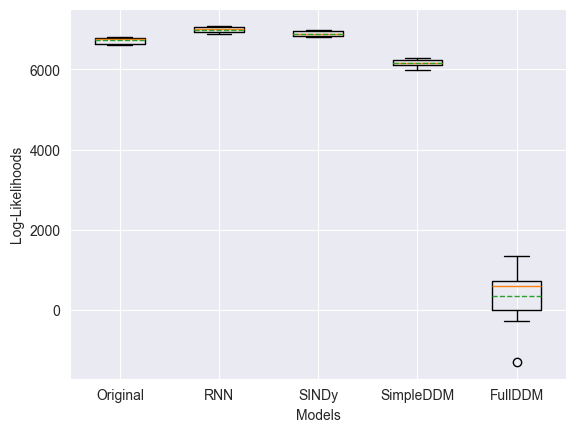

In [135]:
fig, ax = plt.subplots()
ax.boxplot([lls_original_4_0, lls_rnn_4_0, lls_sindy_4_0, lls_simple_ddm_4_0, lls_fullddm_4_0], showmeans=True, meanline=True)
ax.set_xticklabels(['Original', 'RNN', 'SINDy', 'SimpleDDM', 'FullDDM'])
plt.xlabel("Models")
plt.ylabel("Log-Likelihoods")
plt.show()

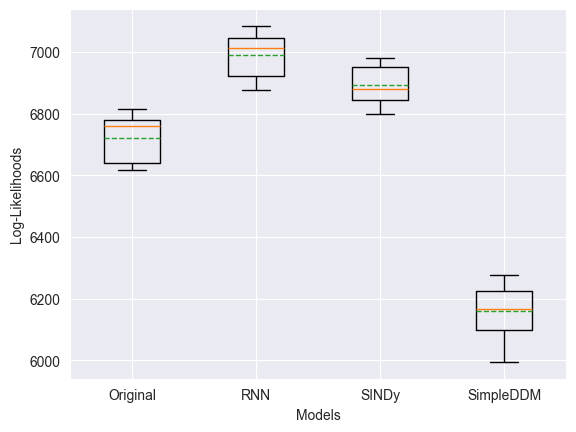

In [136]:
fig, ax = plt.subplots()
ax.boxplot([lls_original_4_0, lls_rnn_4_0, lls_sindy_4_0, lls_simple_ddm_4_0], showmeans=True, meanline=True)
ax.set_xticklabels(['Original', 'RNN', 'SINDy', 'SimpleDDM'])
plt.xlabel("Models")
plt.ylabel("Log-Likelihoods")
plt.show()

In [137]:
lls_original_4_0_norm = lls_original_4_0.mean() / n_sims
lls_rnn_4_0_norm = lls_rnn_4_0.mean() / n_sims
lls_sindy_4_0_norm = lls_sindy_4_0.mean() / n_sims
lls_simple_ddm_4_0_norm = lls_simple_ddm_4_0.mean() / n_sims
lls_fullddm_4_0_norm = lls_fullddm_4_0.mean() / n_sims

In [138]:
print('Normalized LLs')
print(f'Original: {lls_original_4_0_norm}')
print(f'RNN: {lls_rnn_4_0_norm}')
print(f'SINDy: {lls_sindy_4_0_norm}')
print(f'SimpleDDM: {lls_simple_ddm_4_0_norm}')
print(f'FullDDM: {lls_fullddm_4_0_norm}')

Normalized LLs
Original: 0.8204165188197929
RNN: 0.8534344248938135
SINDy: 0.8413998605339097
SimpleDDM: 0.7518476332037837
FullDDM: 0.042208305797623066


In [139]:
p_original_4_0 = lls_original_4_0 / n_sims
p_rnn_4_0 = lls_rnn_4_0 / n_sims
p_sindy_4_0 = lls_sindy_4_0 / n_sims
p_simple_ddm_4_0 = lls_simple_ddm_4_0 / n_sims
p_fullddm_4_0 = lls_fullddm_4_0 / n_sims

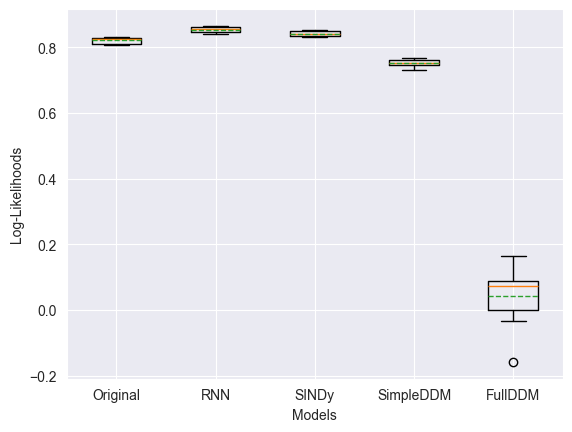

In [140]:
fig, ax = plt.subplots()
ax.boxplot([p_original_4_0, p_rnn_4_0, p_sindy_4_0, p_simple_ddm_4_0, p_fullddm_4_0], showmeans=True, meanline=True)
ax.set_xticklabels(['Original', 'RNN', 'SINDy', 'SimpleDDM', 'FullDDM'])
plt.xlabel("Models")
plt.ylabel("Log-Likelihoods")
plt.show()

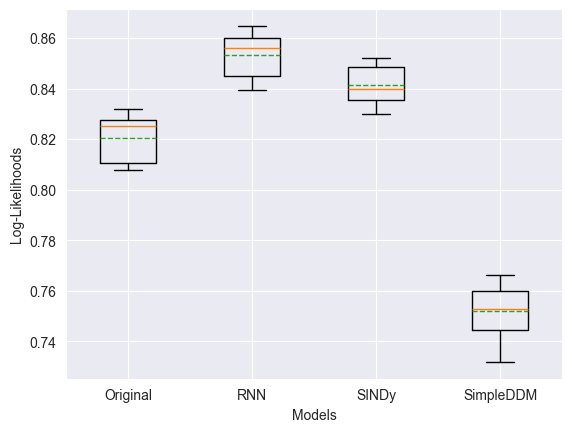

In [141]:
fig, ax = plt.subplots()
ax.boxplot([p_original_4_0, p_rnn_4_0, p_sindy_4_0, p_simple_ddm_4_0], showmeans=True, meanline=True)
ax.set_xticklabels(['Original', 'RNN', 'SINDy', 'SimpleDDM'])
plt.xlabel("Models")
plt.ylabel("Log-Likelihoods")
plt.show()

In [142]:
print(f'LL Original mean: {p_original_4_0.mean()}, std: {p_original_4_0.std()}')
print(f'LL RNN mean: {p_rnn_4_0.mean()}, std: {p_rnn_4_0.std()}')
print(f'LL SINDy mean: {p_sindy_4_0.mean()}, std: {p_sindy_4_0.std()}')
print(f'LL SimpleDDM mean: {p_simple_ddm_4_0.mean()}, std: {p_simple_ddm_4_0.std()}')
print(f'LL FullDDM mean: {p_fullddm_4_0.mean()}, std: {p_fullddm_4_0.std()}')

LL Original mean: 0.8204165188197929, std: 0.009144934563174051
LL RNN mean: 0.8534344248938135, std: 0.008578458403674768
LL SINDy mean: 0.8413998605339097, std: 0.00738833474549473
LL SimpleDDM mean: 0.7518476332037837, std: 0.010321781030189252
LL FullDDM mean: 0.042208305797623066, std: 0.08547724453108868


### v = 2.0

Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.


PyBeam LL Mean: -1016.4113161697836, std: 94.65877826690648
RNN LL Mean: -758.7046248019445, std: 69.77596977191926
SINDy LL Mean: -930.4796287788986, std: 53.14056722886369
SimpleDDM LL Mean: -1656.9442792152272, std: 89.96176998664242
FullDDM LL Mean: -6689.186874698387, std: 463.41718849100766


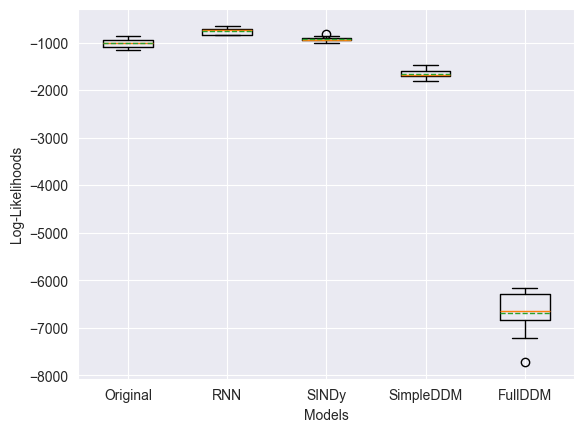

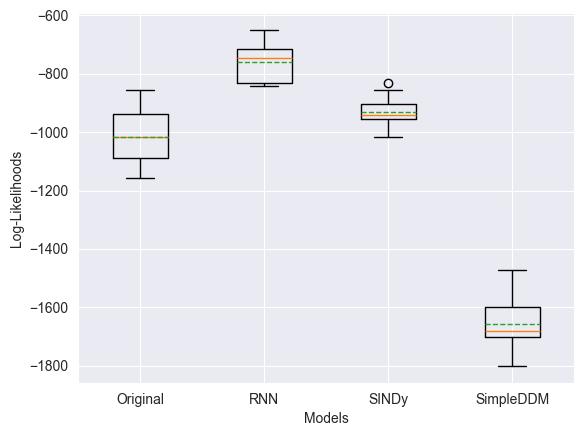

Normalized LLs
Original: -0.12407364699338179
RNN: -0.09261531064476862
SINDy: -0.11358393905992414
SimpleDDM: -0.20226370595889004
FullDDM: -0.8165511321653305


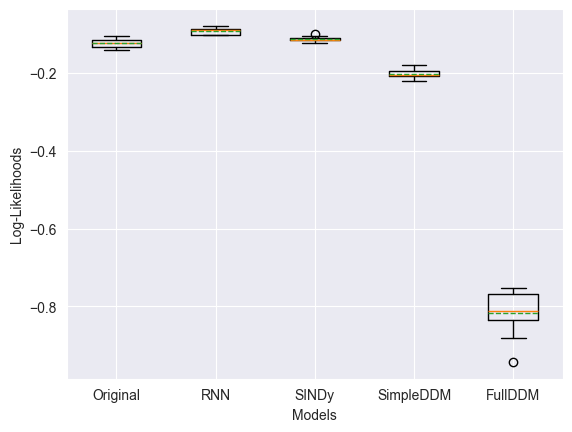

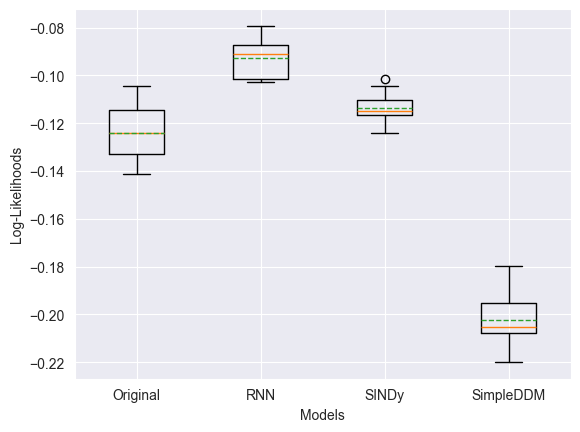

LL Original mean: -0.12407364699338179, std: 0.011555026643909483
LL RNN mean: -0.09261531064476862, std: 0.008517574435048738
LL SINDy mean: -0.11358393905992414, std: 0.006486885648054649
LL SimpleDDM mean: -0.20226370595889004, std: 0.010981661375322561
LL FullDDM mean: -0.8165511321653305, std: 0.05656948101696871


In [143]:
n_trials = 10
n_sims = rts_original_2_0.size

all_rts_original_2_0 = []
all_rts_rnn_2_0 = []
all_rts_sindy_2_0 = []
all_rts_simple_ddm_2_0 = []
all_rts_fullddm_2_0 = []

lls_original_2_0 = []
lls_rnn_2_0 = []
lls_sindy_2_0 = []
lls_simple_ddm_2_0 = []
lls_fullddm_2_0 = []

kde_test = KernelDensity(bandwidth=bandwidth_2_0, kernel=kernel_2_0).fit(rts_original_2_0)

for i in range(n_trials):
    obs, _ = pbc.simulate(n_sims, f"../../{config_2_0['simulation_params']['path_pybeam_model']}", phi_2_0,
                          get_traces=True)

    rts_original = np.concatenate([obs['rt_upper'], -1 * obs['rt_lower']])
    rts_original = np.expand_dims(rts_original, axis=1)
    all_rts_original_2_0.append(rts_original)
    lls_original_2_0.append(kde_test.score(rts_original))

    rts_rnn, traces, dt = rnn_regressor_2_0.predict(np.zeros(n_sims))
    rts_rnn = rts_rnn.reshape(-1, 1)
    all_rts_rnn_2_0.append(rts_rnn)
    lls_rnn_2_0.append(kde_test.score(rts_rnn))

    v_init, D_init = traces['drift'][0][0]
    rts_sindy = sindy_predict(sindy_regressor_2_0.sindy, initial_v=v_init, initial_D=D_init,
                              b=rnn_regressor_2_0.rnn.threshold.item(), n_sims=n_sims, dt=dt[0])
    rts_sindy = np.array(rts_sindy).reshape(-1, 1)
    all_rts_sindy_2_0.append(rts_sindy)
    lls_sindy_2_0.append(kde_test.score(rts_sindy))

    obs = pbp.simulate(N_sims=rts_original_2_0.size, model=simpleDDM, phi=phi_2_0_simpleddm)
    rts_simpleddm_upper = obs['rt_upper']
    rts_simpleddm_lower = obs['rt_lower']
    rts_simpleddm = np.concatenate([rts_simpleddm_upper, -1 * rts_simpleddm_lower]).reshape(-1, 1)
    all_rts_simple_ddm_2_0.append(rts_simpleddm)
    lls_simple_ddm_2_0.append(kde_test.score(rts_simpleddm))

    obs = pbp.simulate(N_sims=rts_original_2_0.size, model=fullDDM, phi=phi_2_0_fullddm)
    rts_fullddm_upper = obs['rt_upper']
    rts_fullddm_lower = obs['rt_lower']
    rts_fullddm = np.concatenate([rts_fullddm_upper, -1 * rts_fullddm_lower]).reshape(-1, 1)
    all_rts_fullddm_2_0.append(rts_fullddm)
    lls_fullddm_2_0.append(kde_test.score(rts_fullddm))
lls_original_2_0 = np.array(lls_original_2_0)
print(f'PyBeam LL Mean: {lls_original_2_0.mean()}, std: {lls_original_2_0.std()}')
lls_rnn_2_0 = np.array(lls_rnn_2_0)
print(f'RNN LL Mean: {lls_rnn_2_0.mean()}, std: {lls_rnn_2_0.std()}')
lls_sindy_2_0 = np.array(lls_sindy_2_0)
print(f'SINDy LL Mean: {lls_sindy_2_0.mean()}, std: {lls_sindy_2_0.std()}')
lls_simple_ddm_2_0 = np.array(lls_simple_ddm_2_0)
print(f'SimpleDDM LL Mean: {lls_simple_ddm_2_0.mean()}, std: {lls_simple_ddm_2_0.std()}')
lls_fullddm_2_0 = np.array(lls_fullddm_2_0)
print(f'FullDDM LL Mean: {lls_fullddm_2_0.mean()}, std: {lls_fullddm_2_0.std()}')
fig, ax = plt.subplots()
ax.boxplot([lls_original_2_0, lls_rnn_2_0, lls_sindy_2_0, lls_simple_ddm_2_0, lls_fullddm_2_0], showmeans=True,
           meanline=True)
ax.set_xticklabels(['Original', 'RNN', 'SINDy', 'SimpleDDM', 'FullDDM'])
plt.xlabel("Models")
plt.ylabel("Log-Likelihoods")
plt.show()
fig, ax = plt.subplots()
ax.boxplot([lls_original_2_0, lls_rnn_2_0, lls_sindy_2_0, lls_simple_ddm_2_0], showmeans=True, meanline=True)
ax.set_xticklabels(['Original', 'RNN', 'SINDy', 'SimpleDDM'])
plt.xlabel("Models")
plt.ylabel("Log-Likelihoods")
plt.show()
lls_original_2_0_norm = lls_original_2_0.mean() / n_sims
lls_rnn_2_0_norm = lls_rnn_2_0.mean() / n_sims
lls_sindy_2_0_norm = lls_sindy_2_0.mean() / n_sims
lls_simple_ddm_2_0_norm = lls_simple_ddm_2_0.mean() / n_sims
lls_fullddm_2_0_norm = lls_fullddm_2_0.mean() / n_sims
print('Normalized LLs')
print(f'Original: {lls_original_2_0_norm}')
print(f'RNN: {lls_rnn_2_0_norm}')
print(f'SINDy: {lls_sindy_2_0_norm}')
print(f'SimpleDDM: {lls_simple_ddm_2_0_norm}')
print(f'FullDDM: {lls_fullddm_2_0_norm}')
p_original_2_0 = lls_original_2_0 / n_sims
p_rnn_2_0 = lls_rnn_2_0 / n_sims
p_sindy_2_0 = lls_sindy_2_0 / n_sims
p_simple_ddm_2_0 = lls_simple_ddm_2_0 / n_sims
p_fullddm_2_0 = lls_fullddm_2_0 / n_sims
fig, ax = plt.subplots()
ax.boxplot([p_original_2_0, p_rnn_2_0, p_sindy_2_0, p_simple_ddm_2_0, p_fullddm_2_0], showmeans=True, meanline=True)
ax.set_xticklabels(['Original', 'RNN', 'SINDy', 'SimpleDDM', 'FullDDM'])
plt.xlabel("Models")
plt.ylabel("Log-Likelihoods")
plt.show()
fig, ax = plt.subplots()
ax.boxplot([p_original_2_0, p_rnn_2_0, p_sindy_2_0, p_simple_ddm_2_0], showmeans=True, meanline=True)
ax.set_xticklabels(['Original', 'RNN', 'SINDy', 'SimpleDDM'])
plt.xlabel("Models")
plt.ylabel("Log-Likelihoods")
plt.show()
print(f'LL Original mean: {p_original_2_0.mean()}, std: {p_original_2_0.std()}')
print(f'LL RNN mean: {p_rnn_2_0.mean()}, std: {p_rnn_2_0.std()}')
print(f'LL SINDy mean: {p_sindy_2_0.mean()}, std: {p_sindy_2_0.std()}')
print(f'LL SimpleDDM mean: {p_simple_ddm_2_0.mean()}, std: {p_simple_ddm_2_0.std()}')
print(f'LL FullDDM mean: {p_fullddm_2_0.mean()}, std: {p_fullddm_2_0.std()}')

### v = 1.0

Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.


PyBeam LL Mean: -7715.802698544651, std: 110.25229148421045
RNN LL Mean: -7814.872656020566, std: 87.63603558921201
SINDy LL Mean: -8009.878245552636, std: 144.61999193932172
SimpleDDM LL Mean: -8080.7630968499525, std: 93.36463877340745
FullDDM LL Mean: -10307.470005823747, std: 293.7236650202062


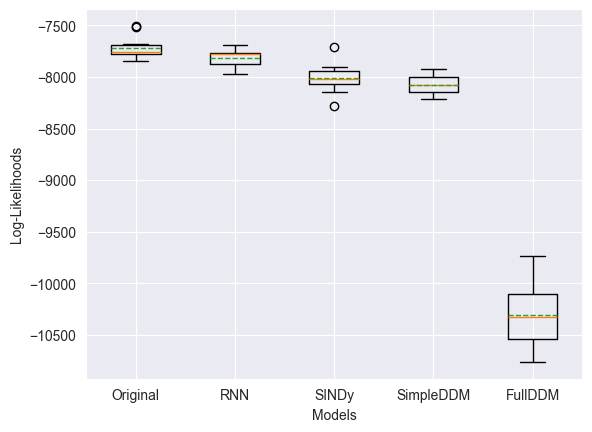

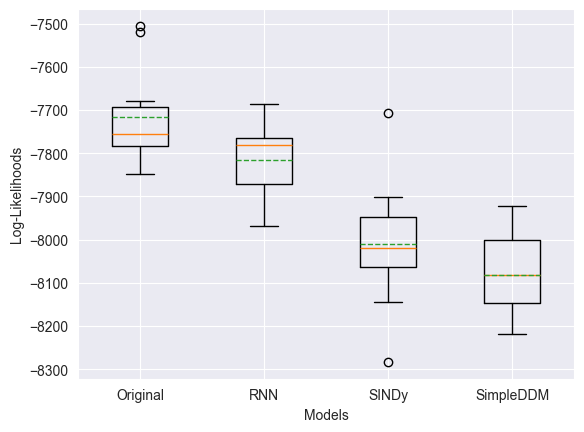

Normalized LLs
Original: -0.9418704465996889
RNN: -0.9539639472681355
SINDy: -0.977768340521562
SimpleDDM: -0.9864212764709415
FullDDM: -1.2582360846952816


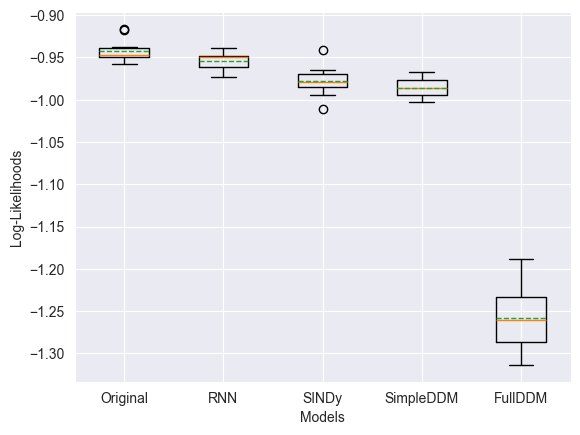

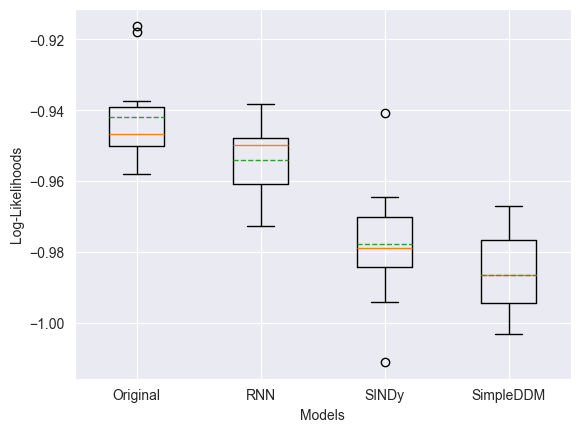

LL Original mean: -0.9418704465996889, std: 0.013458531675318658
LL RNN mean: -0.9539639472681355, std: 0.010697758250636232
LL SINDy mean: -0.977768340521562, std: 0.017653807609780484
LL SimpleDDM mean: -0.9864212764709415, std: 0.011397050631519464
LL FullDDM mean: -1.2582360846952816, std: 0.03585493957766189


In [144]:
n_trials = 10
n_sims = rts_original_1_0.size

all_rts_original_1_0 = []
all_rts_rnn_1_0 = []
all_rts_sindy_1_0 = []
all_rts_simple_ddm_1_0 = []
all_rts_fullddm_1_0 = []

lls_original_1_0 = []
lls_rnn_1_0 = []
lls_sindy_1_0 = []
lls_simple_ddm_1_0 = []
lls_fullddm_1_0 = []

kde_test = KernelDensity(bandwidth=bandwidth_1_0, kernel=kernel_1_0).fit(rts_original_1_0)

for i in range(n_trials):
    obs, _ = pbc.simulate(n_sims, f"../../{config_1_0['simulation_params']['path_pybeam_model']}", phi_1_0,
                          get_traces=True)

    rts_original = np.concatenate([obs['rt_upper'], -1 * obs['rt_lower']])
    rts_original = np.expand_dims(rts_original, axis=1)
    all_rts_original_1_0.append(rts_original)
    lls_original_1_0.append(kde_test.score(rts_original))

    rts_rnn, traces, dt = rnn_regressor_1_0.predict(np.zeros(n_sims))
    rts_rnn = rts_rnn.reshape(-1, 1)
    all_rts_rnn_1_0.append(rts_rnn)
    lls_rnn_1_0.append(kde_test.score(rts_rnn))

    v_init, D_init = traces['drift'][0][0]
    rts_sindy = sindy_predict(sindy_regressor_1_0.sindy, initial_v=v_init, initial_D=D_init,
                              b=rnn_regressor_1_0.rnn.threshold.item(), n_sims=n_sims, dt=dt[0])
    rts_sindy = np.array(rts_sindy).reshape(-1, 1)
    all_rts_sindy_1_0.append(rts_sindy)
    lls_sindy_1_0.append(kde_test.score(rts_sindy))

    obs = pbp.simulate(N_sims=rts_original_1_0.size, model=simpleDDM, phi=phi_1_0_simpleddm)
    rts_simpleddm_upper = obs['rt_upper']
    rts_simpleddm_lower = obs['rt_lower']
    rts_simpleddm = np.concatenate([rts_simpleddm_upper, -1 * rts_simpleddm_lower]).reshape(-1, 1)
    all_rts_simple_ddm_1_0.append(rts_simpleddm)
    lls_simple_ddm_1_0.append(kde_test.score(rts_simpleddm))

    obs = pbp.simulate(N_sims=rts_original_1_0.size, model=fullDDM, phi=phi_1_0_fullddm)
    rts_fullddm_upper = obs['rt_upper']
    rts_fullddm_lower = obs['rt_lower']
    rts_fullddm = np.concatenate([rts_fullddm_upper, -1 * rts_fullddm_lower]).reshape(-1, 1)
    all_rts_fullddm_1_0.append(rts_fullddm)
    lls_fullddm_1_0.append(kde_test.score(rts_fullddm))
lls_original_1_0 = np.array(lls_original_1_0)
print(f'PyBeam LL Mean: {lls_original_1_0.mean()}, std: {lls_original_1_0.std()}')
lls_rnn_1_0 = np.array(lls_rnn_1_0)
print(f'RNN LL Mean: {lls_rnn_1_0.mean()}, std: {lls_rnn_1_0.std()}')
lls_sindy_1_0 = np.array(lls_sindy_1_0)
print(f'SINDy LL Mean: {lls_sindy_1_0.mean()}, std: {lls_sindy_1_0.std()}')
lls_simple_ddm_1_0 = np.array(lls_simple_ddm_1_0)
print(f'SimpleDDM LL Mean: {lls_simple_ddm_1_0.mean()}, std: {lls_simple_ddm_1_0.std()}')
lls_fullddm_1_0 = np.array(lls_fullddm_1_0)
print(f'FullDDM LL Mean: {lls_fullddm_1_0.mean()}, std: {lls_fullddm_1_0.std()}')
fig, ax = plt.subplots()
ax.boxplot([lls_original_1_0, lls_rnn_1_0, lls_sindy_1_0, lls_simple_ddm_1_0, lls_fullddm_1_0], showmeans=True,
           meanline=True)
ax.set_xticklabels(['Original', 'RNN', 'SINDy', 'SimpleDDM', 'FullDDM'])
plt.xlabel("Models")
plt.ylabel("Log-Likelihoods")
plt.show()
fig, ax = plt.subplots()
ax.boxplot([lls_original_1_0, lls_rnn_1_0, lls_sindy_1_0, lls_simple_ddm_1_0], showmeans=True, meanline=True)
ax.set_xticklabels(['Original', 'RNN', 'SINDy', 'SimpleDDM'])
plt.xlabel("Models")
plt.ylabel("Log-Likelihoods")
plt.show()
lls_original_1_0_norm = lls_original_1_0.mean() / n_sims
lls_rnn_1_0_norm = lls_rnn_1_0.mean() / n_sims
lls_sindy_1_0_norm = lls_sindy_1_0.mean() / n_sims
lls_simple_ddm_1_0_norm = lls_simple_ddm_1_0.mean() / n_sims
lls_fullddm_1_0_norm = lls_fullddm_1_0.mean() / n_sims
print('Normalized LLs')
print(f'Original: {lls_original_1_0_norm}')
print(f'RNN: {lls_rnn_1_0_norm}')
print(f'SINDy: {lls_sindy_1_0_norm}')
print(f'SimpleDDM: {lls_simple_ddm_1_0_norm}')
print(f'FullDDM: {lls_fullddm_1_0_norm}')
p_original_1_0 = lls_original_1_0 / n_sims
p_rnn_1_0 = lls_rnn_1_0 / n_sims
p_sindy_1_0 = lls_sindy_1_0 / n_sims
p_simple_ddm_1_0 = lls_simple_ddm_1_0 / n_sims
p_fullddm_1_0 = lls_fullddm_1_0 / n_sims
fig, ax = plt.subplots()
ax.boxplot([p_original_1_0, p_rnn_1_0, p_sindy_1_0, p_simple_ddm_1_0, p_fullddm_1_0], showmeans=True, meanline=True)
ax.set_xticklabels(['Original', 'RNN', 'SINDy', 'SimpleDDM', 'FullDDM'])
plt.xlabel("Models")
plt.ylabel("Log-Likelihoods")
plt.show()
fig, ax = plt.subplots()
ax.boxplot([p_original_1_0, p_rnn_1_0, p_sindy_1_0, p_simple_ddm_1_0], showmeans=True, meanline=True)
ax.set_xticklabels(['Original', 'RNN', 'SINDy', 'SimpleDDM'])
plt.xlabel("Models")
plt.ylabel("Log-Likelihoods")
plt.show()
print(f'LL Original mean: {p_original_1_0.mean()}, std: {p_original_1_0.std()}')
print(f'LL RNN mean: {p_rnn_1_0.mean()}, std: {p_rnn_1_0.std()}')
print(f'LL SINDy mean: {p_sindy_1_0.mean()}, std: {p_sindy_1_0.std()}')
print(f'LL SimpleDDM mean: {p_simple_ddm_1_0.mean()}, std: {p_simple_ddm_1_0.std()}')
print(f'LL FullDDM mean: {p_fullddm_1_0.mean()}, std: {p_fullddm_1_0.std()}')

### v = 0.5

Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.


PyBeam LL Mean: -11414.546041864707, std: 72.25748671247064
RNN LL Mean: -11410.11979175526, std: 91.17530076751632
SINDy LL Mean: -11490.424704948931, std: 84.01513080428963
SimpleDDM LL Mean: -11306.003228065185, std: 70.07962066965747
FullDDM LL Mean: -12070.982033855693, std: 79.58730283491424


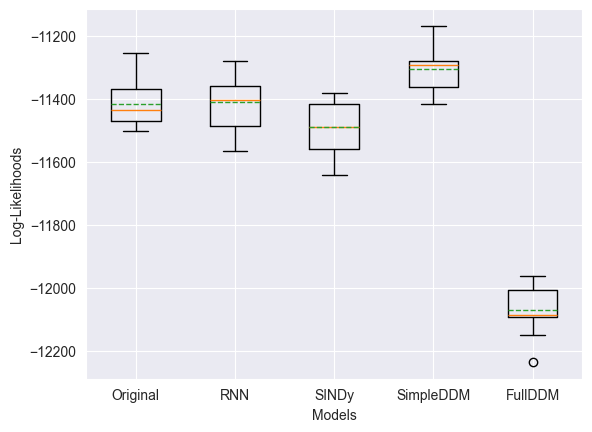

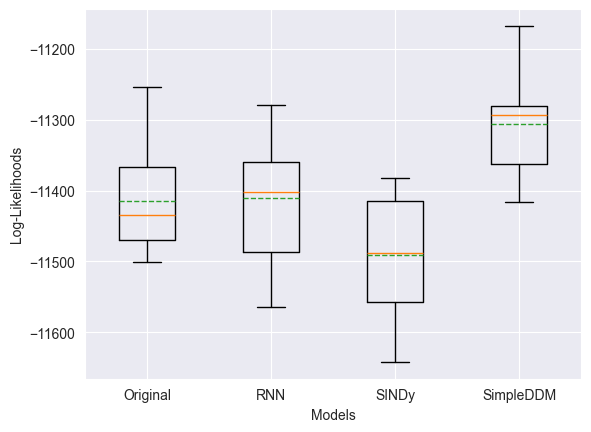

Normalized LLs
Original: -1.3933772023760629
RNN: -1.3928368886419995
SINDy: -1.4026397344908363
SimpleDDM: -1.380127347175926
FullDDM: -1.47350854905465


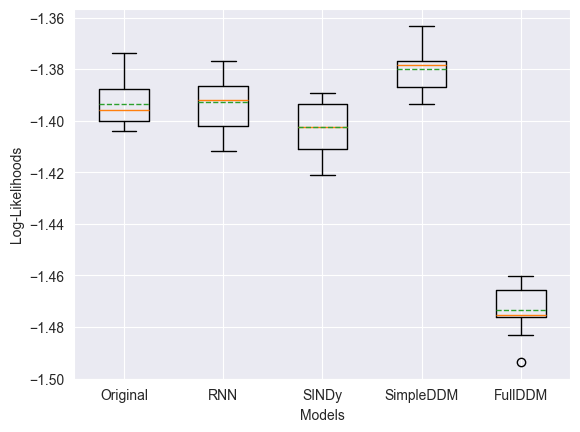

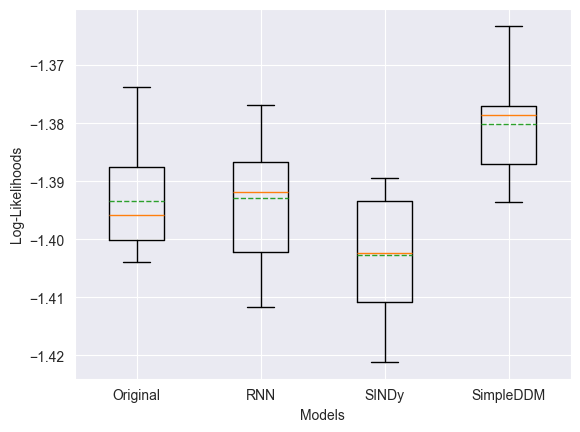

LL Original mean: -1.3933772023760629, std: 0.008820493983455888
LL RNN mean: -1.3928368886419995, std: 0.011129797456972207
LL SINDy mean: -1.4026397344908363, std: 0.010255753272008011
LL SimpleDDM mean: -1.380127347175926, std: 0.008554641195026547
LL FullDDM mean: -1.47350854905465, std: 0.009715246928090117


In [145]:
n_trials = 10
n_sims = rts_original_0_5.size

all_rts_original_0_5 = []
all_rts_rnn_0_5 = []
all_rts_sindy_0_5 = []
all_rts_simple_ddm_0_5 = []
all_rts_fullddm_0_5 = []

lls_original_0_5 = []
lls_rnn_0_5 = []
lls_sindy_0_5 = []
lls_simple_ddm_0_5 = []
lls_fullddm_0_5 = []

kde_test = KernelDensity(bandwidth=bandwidth_0_5, kernel=kernel_0_5).fit(rts_original_0_5)

for i in range(n_trials):
    obs, _ = pbc.simulate(n_sims, f"../../{config_0_5['simulation_params']['path_pybeam_model']}", phi_0_5,
                          get_traces=True)

    rts_original = np.concatenate([obs['rt_upper'], -1 * obs['rt_lower']])
    rts_original = np.expand_dims(rts_original, axis=1)
    all_rts_original_0_5.append(rts_original)
    lls_original_0_5.append(kde_test.score(rts_original))

    rts_rnn, traces, dt = rnn_regressor_0_5.predict(np.zeros(n_sims))
    rts_rnn = rts_rnn.reshape(-1, 1)
    all_rts_rnn_0_5.append(rts_rnn)
    lls_rnn_0_5.append(kde_test.score(rts_rnn))

    v_init, D_init = traces['drift'][0][0]
    rts_sindy = sindy_predict(sindy_regressor_0_5.sindy, initial_v=v_init, initial_D=D_init,
                              b=rnn_regressor_0_5.rnn.threshold.item(), n_sims=n_sims, dt=dt[0])
    rts_sindy = np.array(rts_sindy).reshape(-1, 1)
    all_rts_sindy_0_5.append(rts_sindy)
    lls_sindy_0_5.append(kde_test.score(rts_sindy))

    obs = pbp.simulate(N_sims=rts_original_0_5.size, model=simpleDDM, phi=phi_0_5_simpleddm)
    rts_simpleddm_upper = obs['rt_upper']
    rts_simpleddm_lower = obs['rt_lower']
    rts_simpleddm = np.concatenate([rts_simpleddm_upper, -1 * rts_simpleddm_lower]).reshape(-1, 1)
    all_rts_simple_ddm_0_5.append(rts_simpleddm)
    lls_simple_ddm_0_5.append(kde_test.score(rts_simpleddm))

    obs = pbp.simulate(N_sims=rts_original_0_5.size, model=fullDDM, phi=phi_0_5_fullddm)
    rts_fullddm_upper = obs['rt_upper']
    rts_fullddm_lower = obs['rt_lower']
    rts_fullddm = np.concatenate([rts_fullddm_upper, -1 * rts_fullddm_lower]).reshape(-1, 1)
    all_rts_fullddm_0_5.append(rts_fullddm)
    lls_fullddm_0_5.append(kde_test.score(rts_fullddm))
lls_original_0_5 = np.array(lls_original_0_5)
print(f'PyBeam LL Mean: {lls_original_0_5.mean()}, std: {lls_original_0_5.std()}')
lls_rnn_0_5 = np.array(lls_rnn_0_5)
print(f'RNN LL Mean: {lls_rnn_0_5.mean()}, std: {lls_rnn_0_5.std()}')
lls_sindy_0_5 = np.array(lls_sindy_0_5)
print(f'SINDy LL Mean: {lls_sindy_0_5.mean()}, std: {lls_sindy_0_5.std()}')
lls_simple_ddm_0_5 = np.array(lls_simple_ddm_0_5)
print(f'SimpleDDM LL Mean: {lls_simple_ddm_0_5.mean()}, std: {lls_simple_ddm_0_5.std()}')
lls_fullddm_0_5 = np.array(lls_fullddm_0_5)
print(f'FullDDM LL Mean: {lls_fullddm_0_5.mean()}, std: {lls_fullddm_0_5.std()}')
fig, ax = plt.subplots()
ax.boxplot([lls_original_0_5, lls_rnn_0_5, lls_sindy_0_5, lls_simple_ddm_0_5, lls_fullddm_0_5], showmeans=True,
           meanline=True)
ax.set_xticklabels(['Original', 'RNN', 'SINDy', 'SimpleDDM', 'FullDDM'])
plt.xlabel("Models")
plt.ylabel("Log-Likelihoods")
plt.show()
fig, ax = plt.subplots()
ax.boxplot([lls_original_0_5, lls_rnn_0_5, lls_sindy_0_5, lls_simple_ddm_0_5], showmeans=True, meanline=True)
ax.set_xticklabels(['Original', 'RNN', 'SINDy', 'SimpleDDM'])
plt.xlabel("Models")
plt.ylabel("Log-Likelihoods")
plt.show()
lls_original_0_5_norm = lls_original_0_5.mean() / n_sims
lls_rnn_0_5_norm = lls_rnn_0_5.mean() / n_sims
lls_sindy_0_5_norm = lls_sindy_0_5.mean() / n_sims
lls_simple_ddm_0_5_norm = lls_simple_ddm_0_5.mean() / n_sims
lls_fullddm_0_5_norm = lls_fullddm_0_5.mean() / n_sims
print('Normalized LLs')
print(f'Original: {lls_original_0_5_norm}')
print(f'RNN: {lls_rnn_0_5_norm}')
print(f'SINDy: {lls_sindy_0_5_norm}')
print(f'SimpleDDM: {lls_simple_ddm_0_5_norm}')
print(f'FullDDM: {lls_fullddm_0_5_norm}')
p_original_0_5 = lls_original_0_5 / n_sims
p_rnn_0_5 = lls_rnn_0_5 / n_sims
p_sindy_0_5 = lls_sindy_0_5 / n_sims
p_simple_ddm_0_5 = lls_simple_ddm_0_5 / n_sims
p_fullddm_0_5 = lls_fullddm_0_5 / n_sims
fig, ax = plt.subplots()
ax.boxplot([p_original_0_5, p_rnn_0_5, p_sindy_0_5, p_simple_ddm_0_5, p_fullddm_0_5], showmeans=True, meanline=True)
ax.set_xticklabels(['Original', 'RNN', 'SINDy', 'SimpleDDM', 'FullDDM'])
plt.xlabel("Models")
plt.ylabel("Log-Likelihoods")
plt.show()
fig, ax = plt.subplots()
ax.boxplot([p_original_0_5, p_rnn_0_5, p_sindy_0_5, p_simple_ddm_0_5], showmeans=True, meanline=True)
ax.set_xticklabels(['Original', 'RNN', 'SINDy', 'SimpleDDM'])
plt.xlabel("Models")
plt.ylabel("Log-Likelihoods")
plt.show()
print(f'LL Original mean: {p_original_0_5.mean()}, std: {p_original_0_5.std()}')
print(f'LL RNN mean: {p_rnn_0_5.mean()}, std: {p_rnn_0_5.std()}')
print(f'LL SINDy mean: {p_sindy_0_5.mean()}, std: {p_sindy_0_5.std()}')
print(f'LL SimpleDDM mean: {p_simple_ddm_0_5.mean()}, std: {p_simple_ddm_0_5.std()}')
print(f'LL FullDDM mean: {p_fullddm_0_5.mean()}, std: {p_fullddm_0_5.std()}')

### v = 0.1

Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.
Simulating RTs and evidence traces from RNN...
Done.


PyBeam LL Mean: -12975.542274928423, std: 92.51120683411186
RNN LL Mean: -12949.345728445462, std: 66.52847256933455
SINDy LL Mean: -13008.834918106922, std: 51.750738069846065
SimpleDDM LL Mean: -12916.312554036742, std: 98.02875034790655
FullDDM LL Mean: -13114.692456713921, std: 85.90344430885767


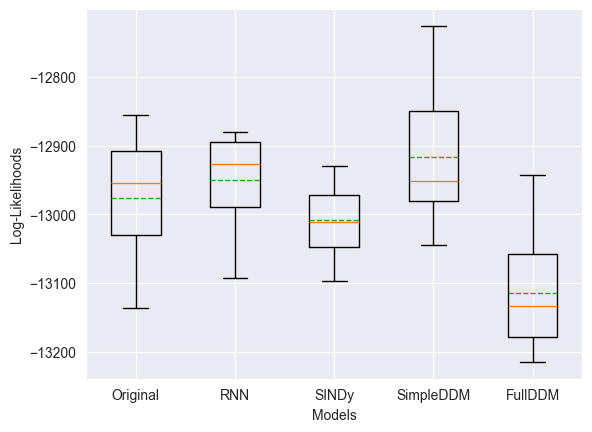

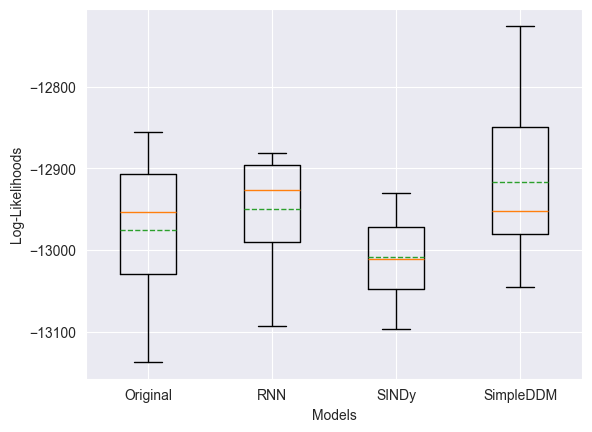

Normalized LLs
Original: -1.5839285003574735
RNN: -1.5807306797418776
SINDy: -1.587992543714224
SimpleDDM: -1.5766983098189382
FullDDM: -1.600914606532461


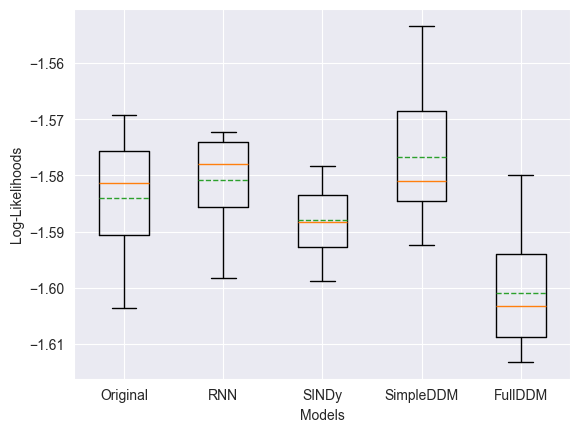

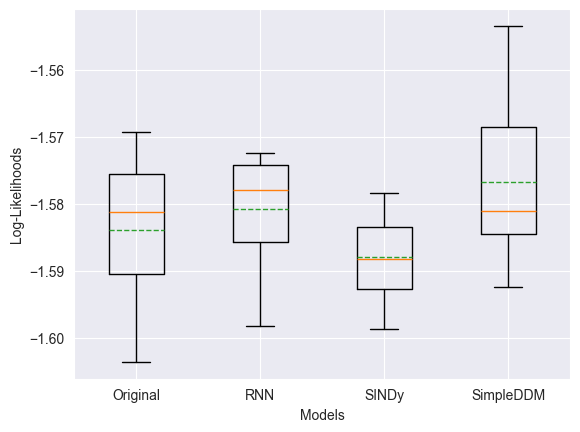

LL Original mean: -1.5839285003574735, std: 0.01129287192799217
LL RNN mean: -1.5807306797418776, std: 0.008121151436686347
LL SINDy mean: -1.587992543714224, std: 0.006317228768291756
LL SimpleDDM mean: -1.5766983098189382, std: 0.011966400188953437
LL FullDDM mean: -1.600914606532461, std: 0.010486260291608603


In [146]:
n_trials = 10
n_sims = rts_original_0_1.size

all_rts_original_0_1 = []
all_rts_rnn_0_1 = []
all_rts_sindy_0_1 = []
all_rts_simple_ddm_0_1 = []
all_rts_fullddm_0_1 = []

lls_original_0_1 = []
lls_rnn_0_1 = []
lls_sindy_0_1 = []
lls_simple_ddm_0_1 = []
lls_fullddm_0_1 = []

kde_test = KernelDensity(bandwidth=bandwidth_0_1, kernel=kernel_0_1).fit(rts_original_0_1)

for i in range(n_trials):
    obs, _ = pbc.simulate(n_sims, f"../../{config_0_1['simulation_params']['path_pybeam_model']}", phi_0_1,
                          get_traces=True)

    rts_original = np.concatenate([obs['rt_upper'], -1 * obs['rt_lower']])
    rts_original = np.expand_dims(rts_original, axis=1)
    all_rts_original_0_1.append(rts_original)
    lls_original_0_1.append(kde_test.score(rts_original))

    rts_rnn, traces, dt = rnn_regressor_0_1.predict(np.zeros(n_sims))
    rts_rnn = rts_rnn.reshape(-1, 1)
    all_rts_rnn_0_1.append(rts_rnn)
    lls_rnn_0_1.append(kde_test.score(rts_rnn))

    v_init, D_init = traces['drift'][0][0]
    rts_sindy = sindy_predict(sindy_regressor_0_1.sindy, initial_v=v_init, initial_D=D_init,
                              b=rnn_regressor_0_1.rnn.threshold.item(), n_sims=n_sims, dt=dt[0])
    rts_sindy = np.array(rts_sindy).reshape(-1, 1)
    all_rts_sindy_0_1.append(rts_sindy)
    lls_sindy_0_1.append(kde_test.score(rts_sindy))

    obs = pbp.simulate(N_sims=rts_original_0_1.size, model=simpleDDM, phi=phi_0_1_simpleddm)
    rts_simpleddm_upper = obs['rt_upper']
    rts_simpleddm_lower = obs['rt_lower']
    rts_simpleddm = np.concatenate([rts_simpleddm_upper, -1 * rts_simpleddm_lower]).reshape(-1, 1)
    all_rts_simple_ddm_0_1.append(rts_simpleddm)
    lls_simple_ddm_0_1.append(kde_test.score(rts_simpleddm))

    obs = pbp.simulate(N_sims=rts_original_0_1.size, model=fullDDM, phi=phi_0_1_fullddm)
    rts_fullddm_upper = obs['rt_upper']
    rts_fullddm_lower = obs['rt_lower']
    rts_fullddm = np.concatenate([rts_fullddm_upper, -1 * rts_fullddm_lower]).reshape(-1, 1)
    all_rts_fullddm_0_1.append(rts_fullddm)
    lls_fullddm_0_1.append(kde_test.score(rts_fullddm))
lls_original_0_1 = np.array(lls_original_0_1)
print(f'PyBeam LL Mean: {lls_original_0_1.mean()}, std: {lls_original_0_1.std()}')
lls_rnn_0_1 = np.array(lls_rnn_0_1)
print(f'RNN LL Mean: {lls_rnn_0_1.mean()}, std: {lls_rnn_0_1.std()}')
lls_sindy_0_1 = np.array(lls_sindy_0_1)
print(f'SINDy LL Mean: {lls_sindy_0_1.mean()}, std: {lls_sindy_0_1.std()}')
lls_simple_ddm_0_1 = np.array(lls_simple_ddm_0_1)
print(f'SimpleDDM LL Mean: {lls_simple_ddm_0_1.mean()}, std: {lls_simple_ddm_0_1.std()}')
lls_fullddm_0_1 = np.array(lls_fullddm_0_1)
print(f'FullDDM LL Mean: {lls_fullddm_0_1.mean()}, std: {lls_fullddm_0_1.std()}')
fig, ax = plt.subplots()
ax.boxplot([lls_original_0_1, lls_rnn_0_1, lls_sindy_0_1, lls_simple_ddm_0_1, lls_fullddm_0_1], showmeans=True,
           meanline=True)
ax.set_xticklabels(['Original', 'RNN', 'SINDy', 'SimpleDDM', 'FullDDM'])
plt.xlabel("Models")
plt.ylabel("Log-Likelihoods")
plt.show()
fig, ax = plt.subplots()
ax.boxplot([lls_original_0_1, lls_rnn_0_1, lls_sindy_0_1, lls_simple_ddm_0_1], showmeans=True, meanline=True)
ax.set_xticklabels(['Original', 'RNN', 'SINDy', 'SimpleDDM'])
plt.xlabel("Models")
plt.ylabel("Log-Likelihoods")
plt.show()
lls_original_0_1_norm = lls_original_0_1.mean() / n_sims
lls_rnn_0_1_norm = lls_rnn_0_1.mean() / n_sims
lls_sindy_0_1_norm = lls_sindy_0_1.mean() / n_sims
lls_simple_ddm_0_1_norm = lls_simple_ddm_0_1.mean() / n_sims
lls_fullddm_0_1_norm = lls_fullddm_0_1.mean() / n_sims
print('Normalized LLs')
print(f'Original: {lls_original_0_1_norm}')
print(f'RNN: {lls_rnn_0_1_norm}')
print(f'SINDy: {lls_sindy_0_1_norm}')
print(f'SimpleDDM: {lls_simple_ddm_0_1_norm}')
print(f'FullDDM: {lls_fullddm_0_1_norm}')
p_original_0_1 = lls_original_0_1 / n_sims
p_rnn_0_1 = lls_rnn_0_1 / n_sims
p_sindy_0_1 = lls_sindy_0_1 / n_sims
p_simple_ddm_0_1 = lls_simple_ddm_0_1 / n_sims
p_fullddm_0_1 = lls_fullddm_0_1 / n_sims
fig, ax = plt.subplots()
ax.boxplot([p_original_0_1, p_rnn_0_1, p_sindy_0_1, p_simple_ddm_0_1, p_fullddm_0_1], showmeans=True, meanline=True)
ax.set_xticklabels(['Original', 'RNN', 'SINDy', 'SimpleDDM', 'FullDDM'])
plt.xlabel("Models")
plt.ylabel("Log-Likelihoods")
plt.show()
fig, ax = plt.subplots()
ax.boxplot([p_original_0_1, p_rnn_0_1, p_sindy_0_1, p_simple_ddm_0_1], showmeans=True, meanline=True)
ax.set_xticklabels(['Original', 'RNN', 'SINDy', 'SimpleDDM'])
plt.xlabel("Models")
plt.ylabel("Log-Likelihoods")
plt.show()
print(f'LL Original mean: {p_original_0_1.mean()}, std: {p_original_0_1.std()}')
print(f'LL RNN mean: {p_rnn_0_1.mean()}, std: {p_rnn_0_1.std()}')
print(f'LL SINDy mean: {p_sindy_0_1.mean()}, std: {p_sindy_0_1.std()}')
print(f'LL SimpleDDM mean: {p_simple_ddm_0_1.mean()}, std: {p_simple_ddm_0_1.std()}')
print(f'LL FullDDM mean: {p_fullddm_0_1.mean()}, std: {p_fullddm_0_1.std()}')